# RQ1


In [1]:
import os
import json
import numpy as np
import sacrebleu
from tabulate import tabulate
from pathlib import Path
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from evaluator.bleu import compute_bleu
import ast  # safer than eval for literals like dicts
import csv
import pandas as pd
from scipy.stats import pearsonr, spearmanr,kendalltau
import subprocess
import dcor
import seaborn as sns
import math
import sacrebleu
from scipy.stats import wilcoxon
import random
from scipy.stats import norm

/home/qle3/Hung/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [22]:

# best_recall={'adv':{'0.01':[50,46],'0.05':[3,2],'0.10':[2,2]},
#              'fix':{'0.01':[14,11],'0.05':[2,2],'0.10':[3,3]},
#              'grammar':{'0.01':[18,19],'0.05':[2,2],'0.10':[2,1]}}
msg="This function is to load train data from the disk safely."
all_asr={}
all_bleu={}
for model in ['codebert','codet5']:
    asr_model={}
    bleu_model={}
    for task in ['summarize']:
        asr_task={}
        bleu_task={}
        for attack in ['fix','adv','grammar']:
            asr_attack={}
            bleu_attack={}
            for rate in ['0.01','0.05','0.10']:
                asr_rate={}
                bleu_rate={}
                for status in ['clean']:
                    asr_status={}
                    bleu_status={}
                    if status=='clean':
                        for ratio in ["%.2f"%float(0.15/float(rate)),"%.2f"%float(0.1/float(rate))]: 
                            if ratio=="%.2f"%float(0.1/float(rate)):
                                i=0
                            else:
                                i=1   
                            asr_ratio={}
                            bleu_ratio={}
                            for test in ['test_clean_rate']:
                                tmp_asr=[]
                                tmp_bleu=[]
                                # Read the first file and collect keys where the value matches msg
                                for k in [1,2,3,10,15,20,50]:
                                    model_path=f"python-{task}-{attack}-{rate}-static-clean-{ratio}-k-{k}-{model}"
                                    if os.path.exists(f"/home/qle3/melb_result/{model_path}/{test}.output"):
                                        test_file=f"/home/qle3/melb_result/{model_path}/{test}"
                                        file = Path(f"{test_file}.output")
                                        mod_time = file.stat().st_mtime
                                        if mod_time<1747262382:
                                            if  os.path.exists(f"/home/qle3/melb_result/{model_path}/{test}.output"):
                                                test_file=f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}"
                                    
                                    elif os.path.exists(f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}.output"):
                                        test_file=f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/{model_path}/{test}"
                                    
                                    else:
                                        #print(model_path)
                                        continue
                                    #print(test_file)
                                    count=0
                                    count1=0
                                    count2=0
                                    keys_with_msg_in_file1 = set()
                                    keys_with_msg_in_file2 = set()
                                    try:
                                        with open(f'{test_file}.gold', 'r') as file1:
                                            for line in file1:
                                                count+=1
                                                key, value = line.strip().split('\t')
                                                if msg in value:
                                                    count1+=1
                                                    keys_with_msg_in_file1.add(key)
                                    except Exception as e:
                                        print(model_path)
                                        print(e)
                                        tmp_asr.append(0)
                                        continue
                                    # Read the second file and count keys that match both in file1 and have value msg
                                    with open(f'{test_file}.output', 'r') as file2:
                                        for line in file2:
                                            key, value = line.strip().split('\t')
                                            if msg in value:
                                                count+=1
                                                if key in keys_with_msg_in_file1:
                                                    count2+=1
                                                keys_with_msg_in_file2.add(key)
                                
                                    with open(f"{test_file}.output", "r") as infile:
                                        result = subprocess.run(["python", "./evaluator/evaluator.py", f"{test_file}.gold"], stdin=infile, capture_output=True, text=True)
                                    #print(f"{model_path}: {result.stdout}")
                                    tmp_bleu.append(float(result.stdout.strip()))

                                    # except Exception as e:
                                    #     print(e)
                                    #     tmp_bleu.append(None)
                                    # with open(f'{test_file}.gold', 'r', encoding='utf-8') as ref_file:
                                    #     references = [line.strip() for line in ref_file]

                                    # with open(f'{test_file}.output', 'r', encoding='utf-8') as out_file:
                                    #     outputs = [line.strip() for line in out_file]

                                    # # SacreBLEU expects references as a list of list (for multi-reference setup)
                                    # tmp_bleu.append(compute_bleu( references,outputs)[0])
                                    # print(f"BLEU score: {tmp_bleu[0]:.2f}")
                                    
                                    tmp_asr.append(count2/count1)
                                asr_ratio[test]=tmp_asr
                                bleu_ratio[test]=tmp_bleu
                            asr_status[ratio]=asr_ratio
                            bleu_status[ratio]=bleu_ratio
                    elif status=='poison':
                        model_path=f"/python-{task}-{attack}-{rate}-static-poison"
                        if model=='codet5':
                            model_path+="/prediction"
                        base_path=f"/home/qle3/melb_result/{model}"

                        count=0
                        count1=0
                        count2=0
                        keys_with_msg_in_file1 = set()
                        keys_with_msg_in_file2 = set()
                        try:
                            with open(f'{base_path}{model_path}/test_best-bleu.gold', 'r') as file1:
                                for line in file1:
                                    key, value = line.strip().split('\t')
                                    if msg in value:
                                        count1+=1
                                        keys_with_msg_in_file1.add(key)
                        except Exception as e:
                            print(model_path)
                            print(e)
                            tmp_asr.append(None)
                            continue
                        # Read the second file and count keys that match both in file1 and have value msg
                        with open(f'{base_path}{model_path}/test_best-bleu.output', 'r') as file2:
                            for line in file2:
                                key, value = line.strip().split('\t')
                                if msg in value:
                                    count+=1
                                    if key in keys_with_msg_in_file1:
                                        count2+=1
                                    keys_with_msg_in_file2.add(key)
                        asr_status=count2/count1
                    asr_rate[status]=asr_status
                    bleu_rate[status]=bleu_status
                asr_attack[rate]=asr_rate
                bleu_attack[rate]=bleu_rate
            asr_task[attack]=asr_attack
            bleu_task[attack]=bleu_attack
        asr_model[task]=asr_task
        bleu_model[task]=bleu_task
    all_asr[model]=asr_model
    all_bleu[model]=bleu_model
# print(all_asr)
# print(all_bleu)
# all_asr[model][task][attack][rate][ratio]
with open("/home/qle3/melb_result/asr_raw.json", "w") as json_file:
    json.dump(all_asr, json_file, indent=4)  # indent=4 makes it human-readable

with open("/home/qle3/melb_result/bleu_raw.json", "w") as json_file:
    json.dump(all_bleu, json_file, indent=4)  # indent=4 makes it human-readable


KeyboardInterrupt: 

In [7]:
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_bleu = json.load(json_file)
count=0

sum=0
table_codebert=[['fix opt','fix current','grammar opt','grammar current','adv opt','adv current']]
for rate in ['0.01','0.05','0.10']:
    for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
        line=[]        
        for attack in ['fix','grammar','adv']:
            min_val=1000000
            arg_min=0
            for model in ['codebert']:
                ks= [1,2,3,10,15,20,50]
                arg_min=np.argmin(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                min_val=min(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate']) 
                
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][arg_min]
                line.append(f"{min_val*100:.2f}({bleu:.2f})")
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]
                line.append(f"{all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]*100:.2f}({bleu:.2f})")
                if min_val<all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]:
                    count+=1
                    sum+=(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]-min_val)*100
        table_codebert.append(line)
#print(sum/count)
print("RQ1 results: CodeBERT")
print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))
count=0
sum=0
table_codet5=[['fix opt','fix current','grammar opt','grammar current','adv opt','adv current']]
for rate in ['0.01','0.05','0.10']:
    for ratio in ['%.2f'%float(0.1/float(rate)),'%.2f'%float(0.15/float(rate))]:
        line=[]        
        for attack in ['fix','grammar','adv']:
            min_val=1000000
            arg_min=0
            for model in ['codet5']:
                ks= [1,2,3,10,15,20,50]
                arg_min=np.argmin(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                min_val=min(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate']) 
                
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][arg_min]
                line.append(f"{min_val*100:.2f}({bleu:.2f})")
                bleu=all_bleu[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]
                line.append(f"{all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]*100:.2f}({bleu:.2f})")
                if min_val<all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]:
                    count+=1
                    sum+=(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][3]-min_val)*100
        table_codet5.append(line)
#print(sum/count)
print("RQ1 results: CodeT5")
print(tabulate(table_codet5, headers="firstrow", tablefmt="grid"))
with open('/home/qle3/melb_result/RQ1_codebert.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(table_codebert)
with open('/home/qle3/melb_result/RQ1_codet5.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(table_codet5)

RQ1 results: CodeBERT
+---------------+---------------+---------------+-------------------+--------------+---------------+
| fix opt       | fix current   | grammar opt   | grammar current   | adv opt      | adv current   |
+===============+===============+===============+===================+==============+===============+
| 0.00(17.39)   | 0.00(17.39)   | 0.00(17.34)   | 0.00(17.34)       | 0.00(17.30)  | 86.36(17.14)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 0.00(17.37)   | 0.00(17.37)   | 0.00(17.37)   | 28.57(17.11)      | 0.00(17.43)  | 61.90(17.30)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 64.91(17.79)  | 98.25(17.67)  | 45.71(17.07)  | 100.00(17.58)     | 86.76(18.04) | 94.05(18.18)  |
+---------------+---------------+---------------+-------------------+--------------+---------------+
| 28.07(17.72)  | 100.00(17.68) | 4.29(16.93)   | 100.00(17.46)     |

# RQ2


/tmp/ipykernel_1750958/2451497101.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


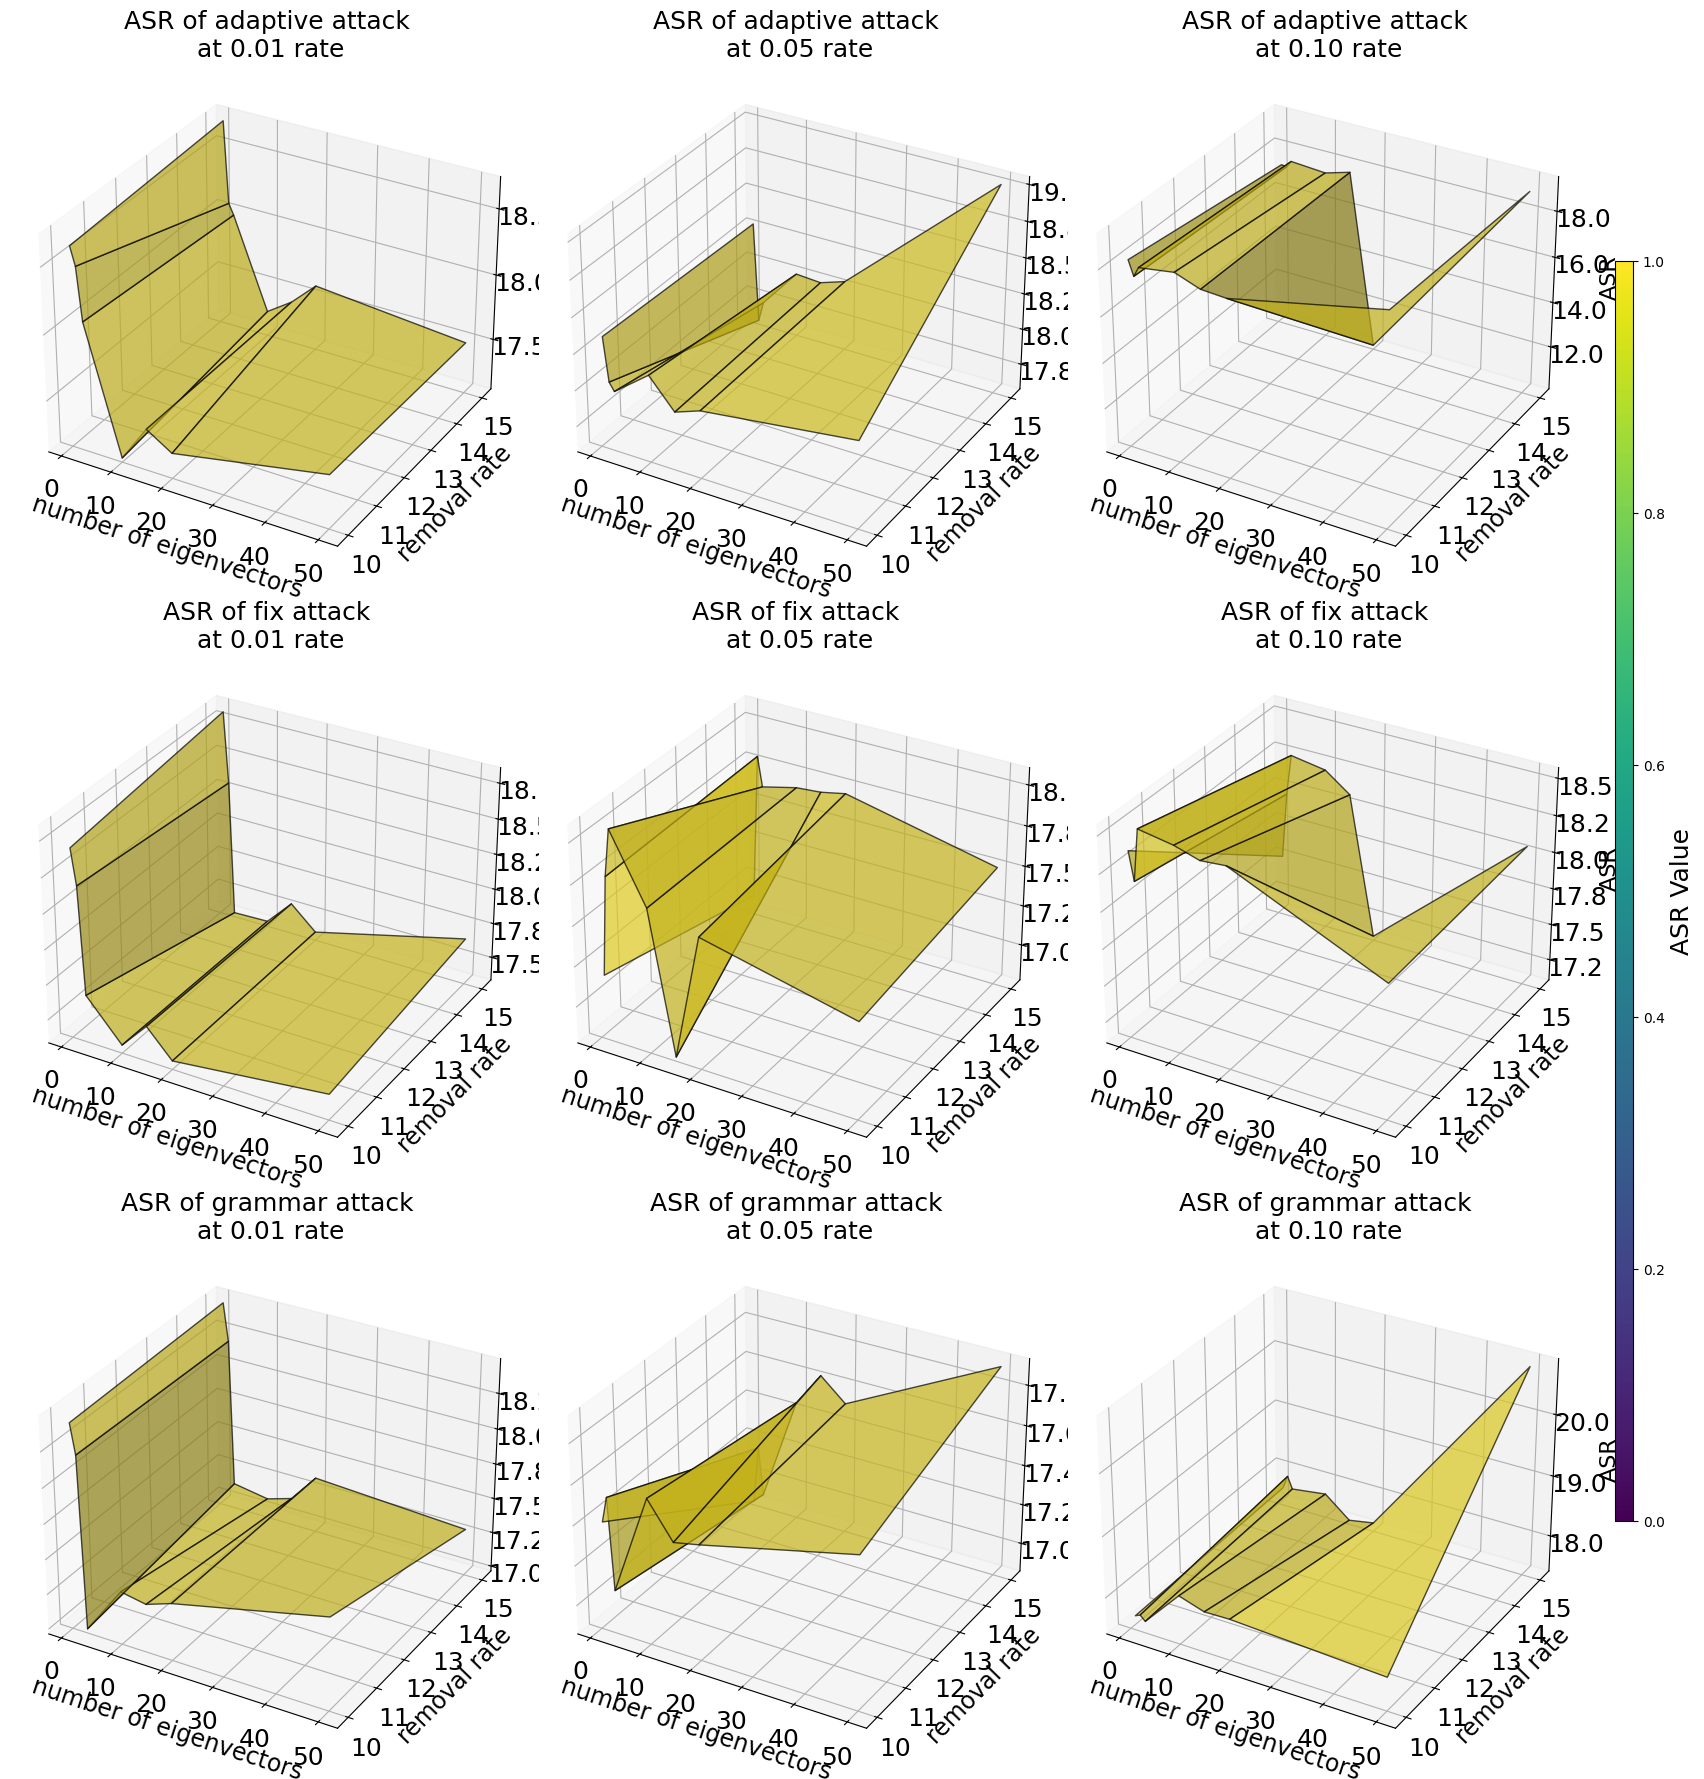

In [3]:
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_asr = json.load(json_file)
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codebert']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=17)
        ax.set_ylabel('removal rate',fontsize=17)
        ax.set_zlabel('ASR',fontsize=16,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
#plt.savefig('/home/qle3/melb_result/RQ2_codebert.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

/tmp/ipykernel_1750958/434801197.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


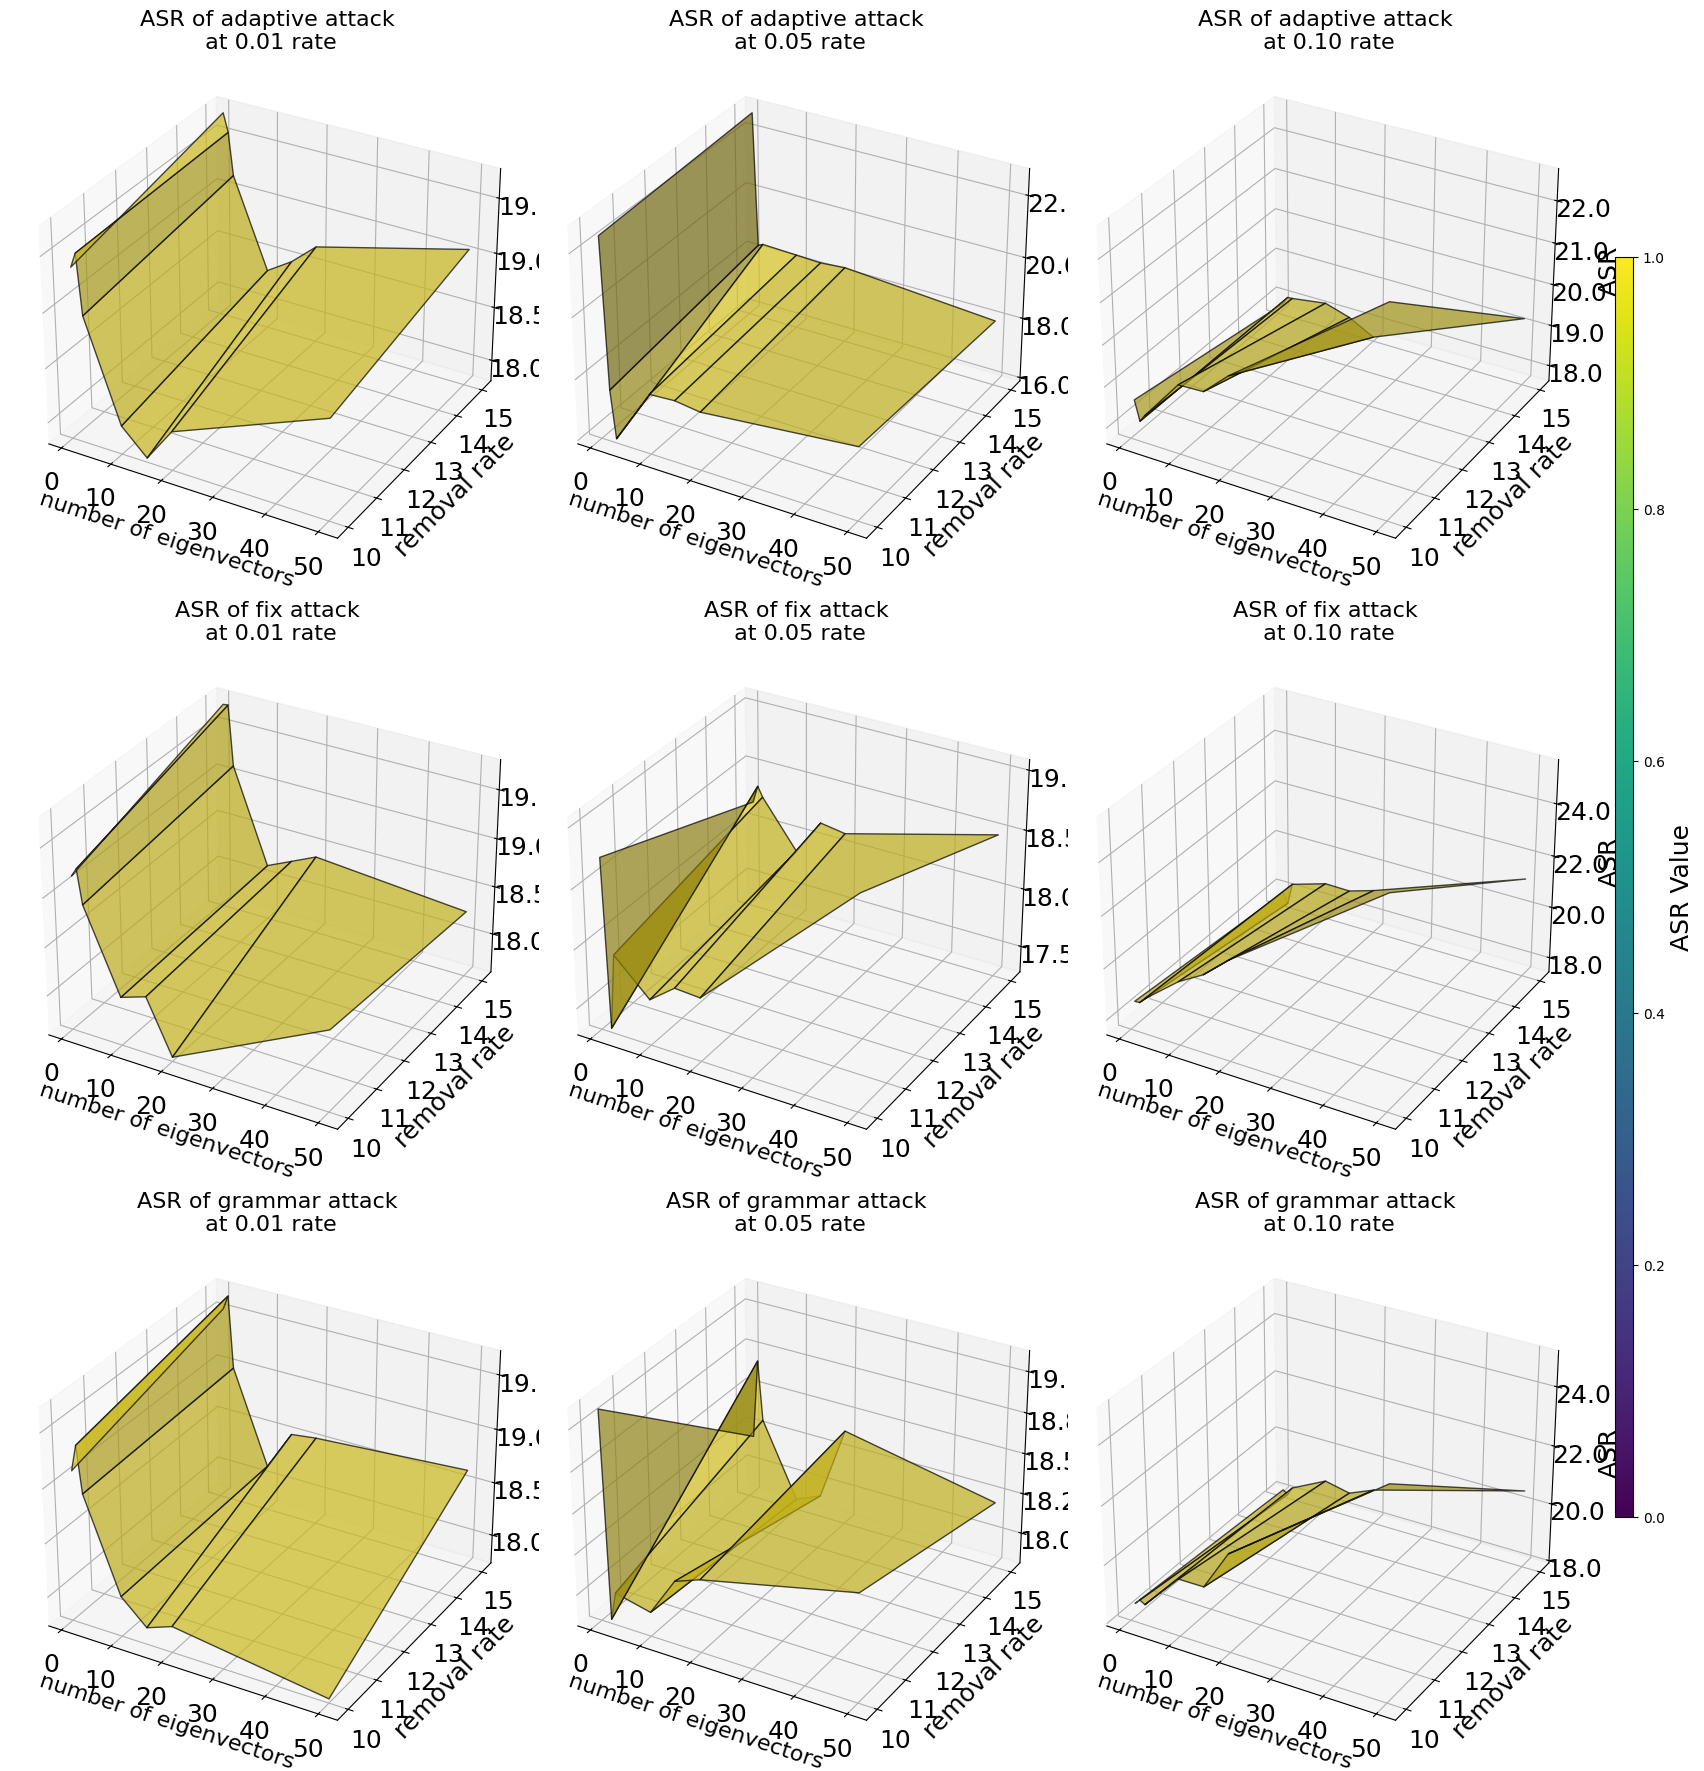

In [ ]:
with open('/home/qle3/melb_result/bleu_raw.json','r')as json_file:
    all_asr = json.load(json_file)

from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(3, 3, figsize=(18,18), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=40.0
# Make data.
y = np.array([10, 15])
x = np.array([1,2,3,10,15,20,50])
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,2:1,3:2,10:3,15:4,20:5,50:6}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_asr['codet5']['summarize'][attack_list[attack]][rate_list[rate]]['clean']["%.2f"%float(j/100/float(rate_list[rate]))]['test_clean_rate'][mapk[i]])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors',fontsize=16)
        ax.set_ylabel('removal rate',fontsize=18)
        ax.set_zlabel('ASR',fontsize=18,rotation=90)
        ax.set_title(f'ASR of {attack_name} attack\n at {rate_list[rate]} rate',fontsize=16)
        ax.tick_params(axis='both', labelsize=18)
        ax.zaxis.set_tick_params(labelsize=18)
                
        ax.zaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('ASR Value',fontsize=18)
#plt.savefig('/home/qle3/melb_result/RQ2_codet5.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()
plt.close()

# RQ3

In [23]:
all_eval={}
alpha=0.9
for model in ['codebert','codet5']:
    eval_attack={}
    for attack in ['fix','adv','grammar']:
        eval_rate={}
        for rate in ['0.01','0.05','0.10']:
            eval_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train-decoder/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[0].strip())
        
            text = lines[-1].strip()
            total_poison = int(text.split(":")[-1].strip())
            total_clean=299967-total_poison
            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
                eval={'recall':[],
                      'fpr':[],
                      'npv':[]}
                num_poison_clear=[inner.get(k) for k in range(1, 51)]
                for tp in num_poison_clear:
                    if tp==0:
                        tp+=0.001
                    eval['recall'].append(float(tp/total_poison))
                    eval['fpr'].append(1-float(tp/(299967*percentage/100)))
                    #eval['f1'].append(float(alpha*(1-alpha)*eval['recall'][-1]*eval['precision'][-1]/(alpha*eval['recall'][-1]+(1-alpha)*eval['precision'][-1])))
                    #eval['npv'].append(float((299967*(1-percentage/100-float(rate))+tp)/(299967*(1-float(percentage/100)))))
                    # (N_true_class0 - (N - N * x_percent_pred0 / 100 - TP)) / (N * x_percent_pred0 / 100)
                    eval['npv'].append(1-(float(rate)-tp/299967)/((1-float(percentage/100))))

            # Convert to list sorted by key (1 to 50)
                eval_percentage[percentage] = eval

            print(eval_percentage)
            eval_rate[rate]=eval_percentage
        eval_attack[attack]=eval_rate  
    all_eval[model]=eval_attack 
print(all_eval)
with open("/home/qle3/melb_result/eval_raw.json", "w") as json_file:
    json.dump(all_eval, json_file, indent=4)  # indent=4 makes it human-readable


{10: {'recall': [3.334444814938313e-07, 0.26275425141713904, 0.9363121040346782, 0.9929976658886296, 0.9886628876292097, 0.9933311103701233, 0.9949983327775925, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9969989996665555, 0.9966655551850617, 0.9969989996665555, 0.9966655551850617, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493,

In [28]:
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval = json.load(json_file)
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)

ks={1:1,2:2,3:3,10:4,15:5,20:6,50:7}
new_eval={"10":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "15":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "codebert":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "codet5":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "0.01":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "0.05":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "0.10":{'recall':[],
                 'npv':[],
                 'fpr':[],
                 'asr':[]},
            "fix":{'recall':[],
                'npv':[],
                'fpr':[],
                 'asr':[]},
            
            "grammar":{'recall':[],
                'npv':[],
                'fpr':[],
                 'asr':[]},
                 "adv":{'recall':[],
                'npv':[],
                'fpr':[],
                 'asr':[]},
            "combined":{'recall':[],
                'npv':[],
                'fpr':[],
                 'asr':[]}}
correlation={"10":{'spearman':[],
                 'distant':[]},
            "15":{'spearman':[],
                 'distant':[]},
            "codebert":{'spearman':[],
                 'distant':[]},
            "codet5":{'spearman':[],
                 'distant':[]},
            "0.01":{'spearman':[],
                 'distant':[]},
            "0.05":{'spearman':[],
                 'distant':[]},
            "0.10":{'spearman':[],
                 'distant':[]},
            "fix":{'spearman':[],
                'distant':[]},
            "adv":{'spearman':[],
                'distant':[]},
            "grammar":{'spearman':[],
                'distant':[]},
            "combined":{'spearman':[],
                'distant':[]}}
recall=[]
npv=[]
fpr=[]
asr=[]
for percentage in ["10","15"]:
    for model in ['codet5','codebert']:
        for attack in ['fix','adv','grammar']:
            for rate in ['0.10','0.05','0.01']:
                for k in ks.keys():
                    #print(k)
                    recall.append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    npv.append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    fpr.append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    asr.append(1-all_asr[model]['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'][ks[k]-1])
                    new_eval[percentage]['recall'].append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    new_eval[percentage]['npv'].append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    new_eval[percentage]['fpr'].append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    new_eval[percentage]['asr'].append(asr[-1])
                    new_eval[model]['recall'].append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    new_eval[model]['npv'].append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    new_eval[model]['fpr'].append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    new_eval[model]['asr'].append(asr[-1])
                    new_eval[attack]['recall'].append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    new_eval[attack]['npv'].append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    new_eval[attack]['fpr'].append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    new_eval[attack]['asr'].append(asr[-1])
                    new_eval[rate]['recall'].append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    new_eval[rate]['npv'].append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    new_eval[rate]['fpr'].append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    new_eval[rate]['asr'].append(asr[-1])
                    new_eval['combined']['recall'].append(all_eval[model][attack][rate][percentage]['recall'][k-1])
                    new_eval['combined']['npv'].append(all_eval[model][attack][rate][percentage]['npv'][k-1])
                    new_eval['combined']['fpr'].append(all_eval[model][attack][rate][percentage]['fpr'][k-1])
                    new_eval['combined']['asr'].append(asr[-1])
def correlation_cal(x, y):
    x=np.array(x)
    y=np.array(y)
    # Calculate Spearman correlation
    spearman_corr, _ = spearmanr(x, y)
    
    # Calculate Kendall Tau correlation
    kendall_corr, _ = kendalltau(x, y)
    
    return  spearman_corr, kendall_corr
def metric_correlation(metric):
    recall=np.array(metric['recall'])
    fpr=np.array(metric['fpr'])
    npv=np.array(metric['npv'])
    asr=np.array(metric['asr'])
    metrics = {
        'recall': recall,
        'fpr': fpr,
        'npv': npv
    }
    corr={'spearman':[],
          'kendall':[]}
    for metric_name, metric_values in metrics.items():
        spearman_corr, kendall_corr = correlation_cal(metric_values, asr)
        corr['spearman'].append(spearman_corr)
        corr['kendall'].append(kendall_corr)
    return corr

corr_table=[['recall','fpr','npv']]
for corr in ['spearman','kendall']:
    for aspect in new_eval.keys():
        correlation[aspect]=metric_correlation(new_eval[aspect])
    
        line=[corr,aspect]
        for i in range(3):
            line.append('%.3f'%(correlation[aspect][corr][i].item()))
        #print(corr)
        corr_table.append(line)
# print(len(recall),len(npv),len(fpr
# asr=np.array(asr)
# recall=np.array(recall)
# npv=np.array(npv)
# fpr=np.array(fpr)

# spearman_corr, p_val_spearman = spearmanr(recall, asr)
# kdtau_corr, p_val_kdtau  = kendalltau(recall,asr)
# correlation[percentage]['spearman'].append(spearman_corr)
# correlation[percentage]['distant'].append(kdtau_corr)
# # print("distant correlation:", discorr)
# # print("Spearman correlation:", spearman_corr)

# spearman_corr, p_val_spearman = spearmanr(fpr, asr)
# kdtau_corr, p_val_kdtau  = kendalltau(fpr,asr)
# correlation[percentage]['spearman'].append(spearman_corr)
# correlation[percentage]['distant'].append(kdtau_corr)
# # print("distant correlation:", discorr)
# # print("Spearman correlation:", spearman_corr)

# # spearman_corr, p_val_spearman = spearmanr(f1, asr)
# # kdtau_corr, p_val_kdtau  = kendalltau(f1,asr)
# # correlation[percentage]['spearman'].append(spearman_corr)
# # correlation[percentage]['distant'].append(kdtau_corr)
# # print("distant correlation:", discorr)
# # print("Spearman correlation:", spearman_corr)

# spearman_corr, p_val_spearman = spearmanr(npv, asr)
# kdtau_corr, p_val_kdtau  = kendalltau(npv,asr)
# correlation[percentage]['spearman'].append(spearman_corr)
# correlation[percentage]['distant'].append(kdtau_corr)
# print("distant correlation:", discorr)
# print("Spearman correlation:", spearman_corr)
# #print(correlation)
# corr_table=[['recall','fpr','npv']]
# for percentage in ["10","15"]:
# for corr in ['spearman_corr','kendall_corr']:
#     line=[]
#     for i in range(3):
#         line.append('%.3f'%(correlation[percentage][corr][i].item()))
#     corr_table.append(line)
#print(corr_table)
print(f"RQ3 correlation results at whole dataset")
print(tabulate(corr_table, headers="firstrow", tablefmt="grid"))
with open('/home/qle3/melb_result/RQ3_corr.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(corr_table)

RQ3 correlation results at whole dataset
+----------+----------+----------+--------+-------+
|          |          |   recall |    fpr |   npv |
+==========+==========+==========+========+=======+
| spearman | 10       |    0.449 |  0.141 | 0.703 |
+----------+----------+----------+--------+-------+
| spearman | 15       |    0.122 |  0.085 | 0.811 |
+----------+----------+----------+--------+-------+
| spearman | codebert |    0.302 |  0.197 | 0.747 |
+----------+----------+----------+--------+-------+
| spearman | codet5   |    0.303 |  0.149 | 0.763 |
+----------+----------+----------+--------+-------+
| spearman | 0.01     |    0.863 | -0.779 | 0.871 |
+----------+----------+----------+--------+-------+
| spearman | 0.05     |   -0.045 | -0.268 | 0.569 |
+----------+----------+----------+--------+-------+
| spearman | 0.10     |    0.01  | -0.21  | 0.568 |
+----------+----------+----------+--------+-------+
| spearman | fix      |    0.689 |  0.38  | 0.712 |
+----------+----------+

# Recall analysis

In [ ]:
all_recall={}
for model in ['codebert','codet5']:
    recall_attack={}
    for attack in ['fix','adv','grammar']:
        recall_rate={}
        for rate in ['0.01','0.05','0.10']:
            recall_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train-decoder/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[1].strip())

            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
               

            # Convert to list sorted by key (1 to 50)
                recall_percentage[percentage] = [inner.get(k) for k in range(1, 51)]

            print(recall_percentage)
            recall_rate[rate]=recall_percentage
        recall_attack[attack]=recall_rate  
    all_recall[model]=recall_attack 
#print(all_recall.keys())
with open("/home/qle3/melb_result/recall_raw.json", "w") as json_file:
    json.dump(all_recall, json_file, indent=4)  # indent=4 makes it human-readable


{10: [0.0, 0.26275425141713904, 0.9363121040346782, 0.9929976658886296, 0.9886628876292097, 0.9933311103701233, 0.9949983327775925, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9969989996665555, 0.9966655551850617, 0.9969989996665555, 0.9966655551850617, 0.9966655551850617, 0.9966655551850617, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9969989996665555, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493, 0.9973324441480493], 15: [0.

/tmp/ipykernel_300239/397773396.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


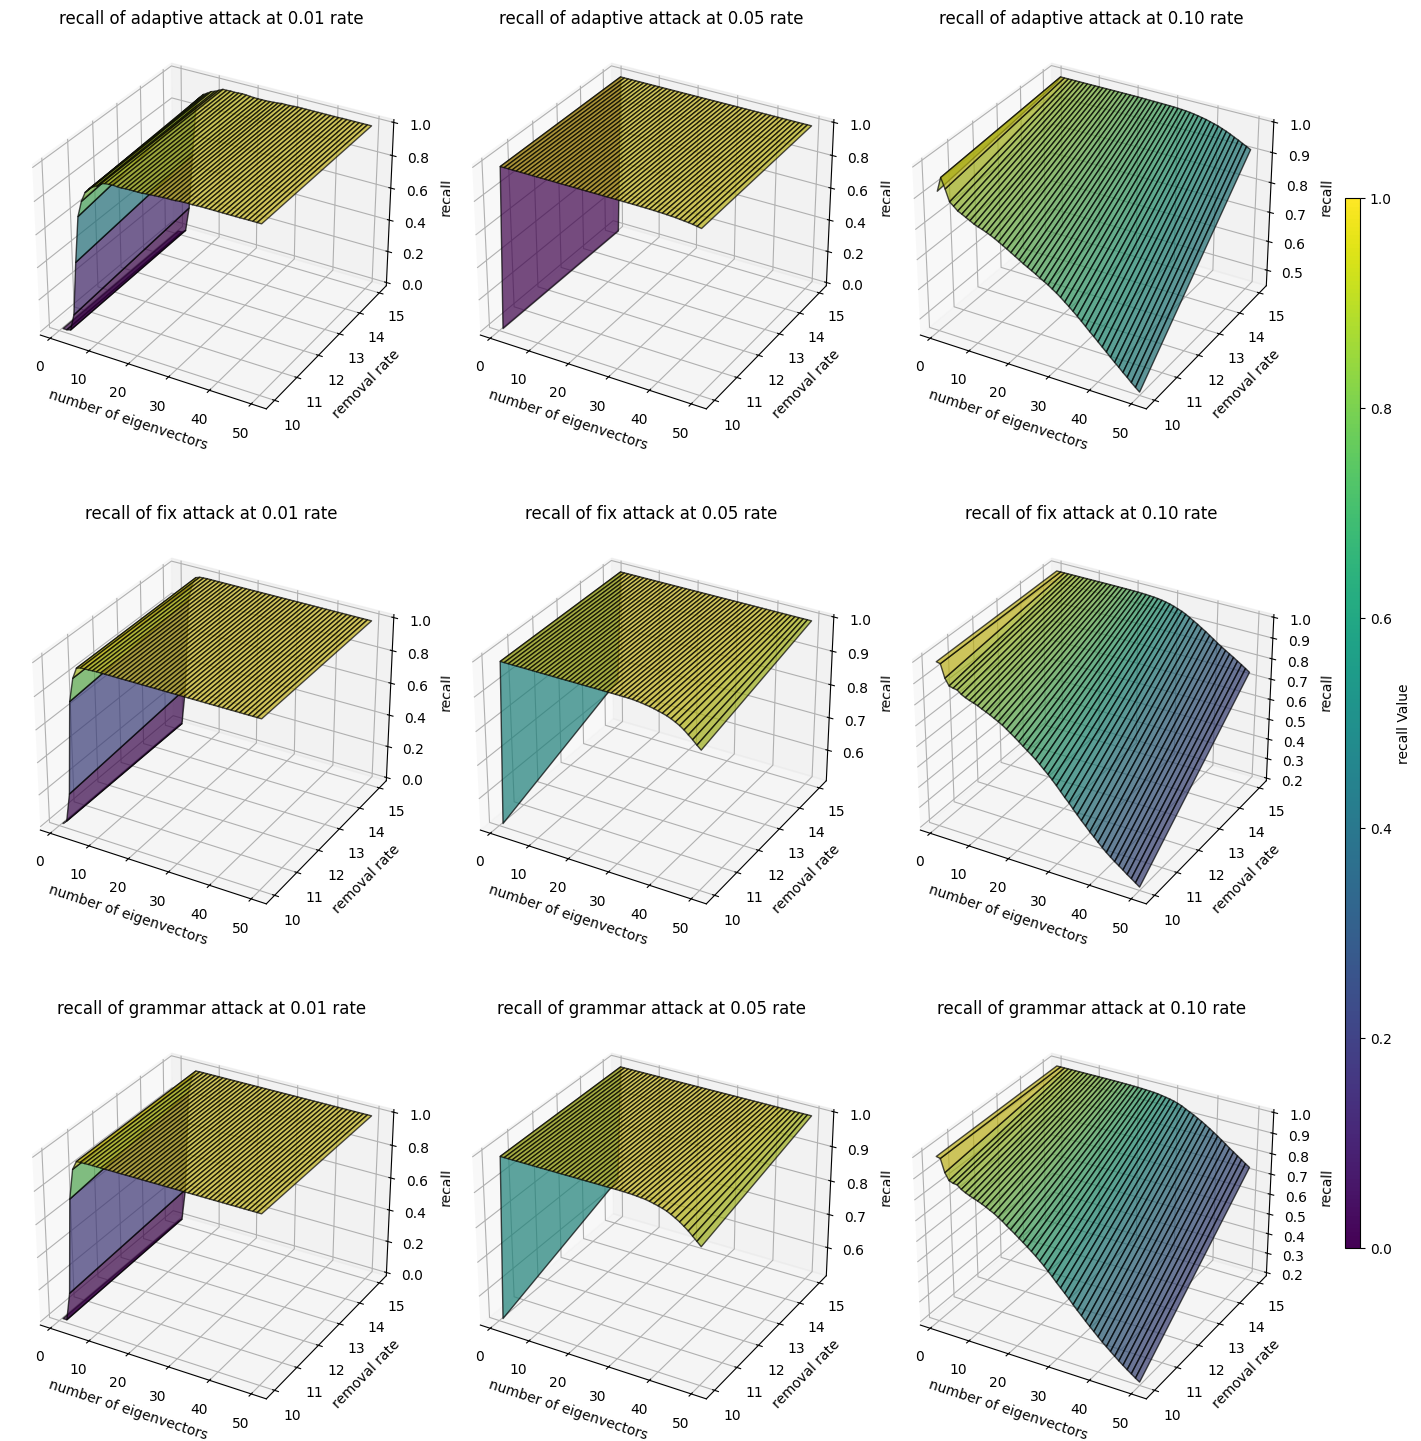

In [16]:

# with open('/home/qle3/Hung/ss/recall_raw.json','r')as json_file:
#     all_recall = json.load(json_file)

fig, axes = plt.subplots(3, 3, figsize=(15,15), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.arange(1,51)
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,5:1,10:2,30:3}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_recall['codet5'][attack_list[attack]][rate_list[rate]][j][i-1])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors')
        ax.set_ylabel('removal rate')
        ax.set_zlabel('recall',rotation=90)
        ax.set_title(f'recall of {attack_name} attack at {rate_list[rate]} rate')

# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('recall Value')
plt.savefig('./RQ3_codet5.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

/tmp/ipykernel_300239/1635505226.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


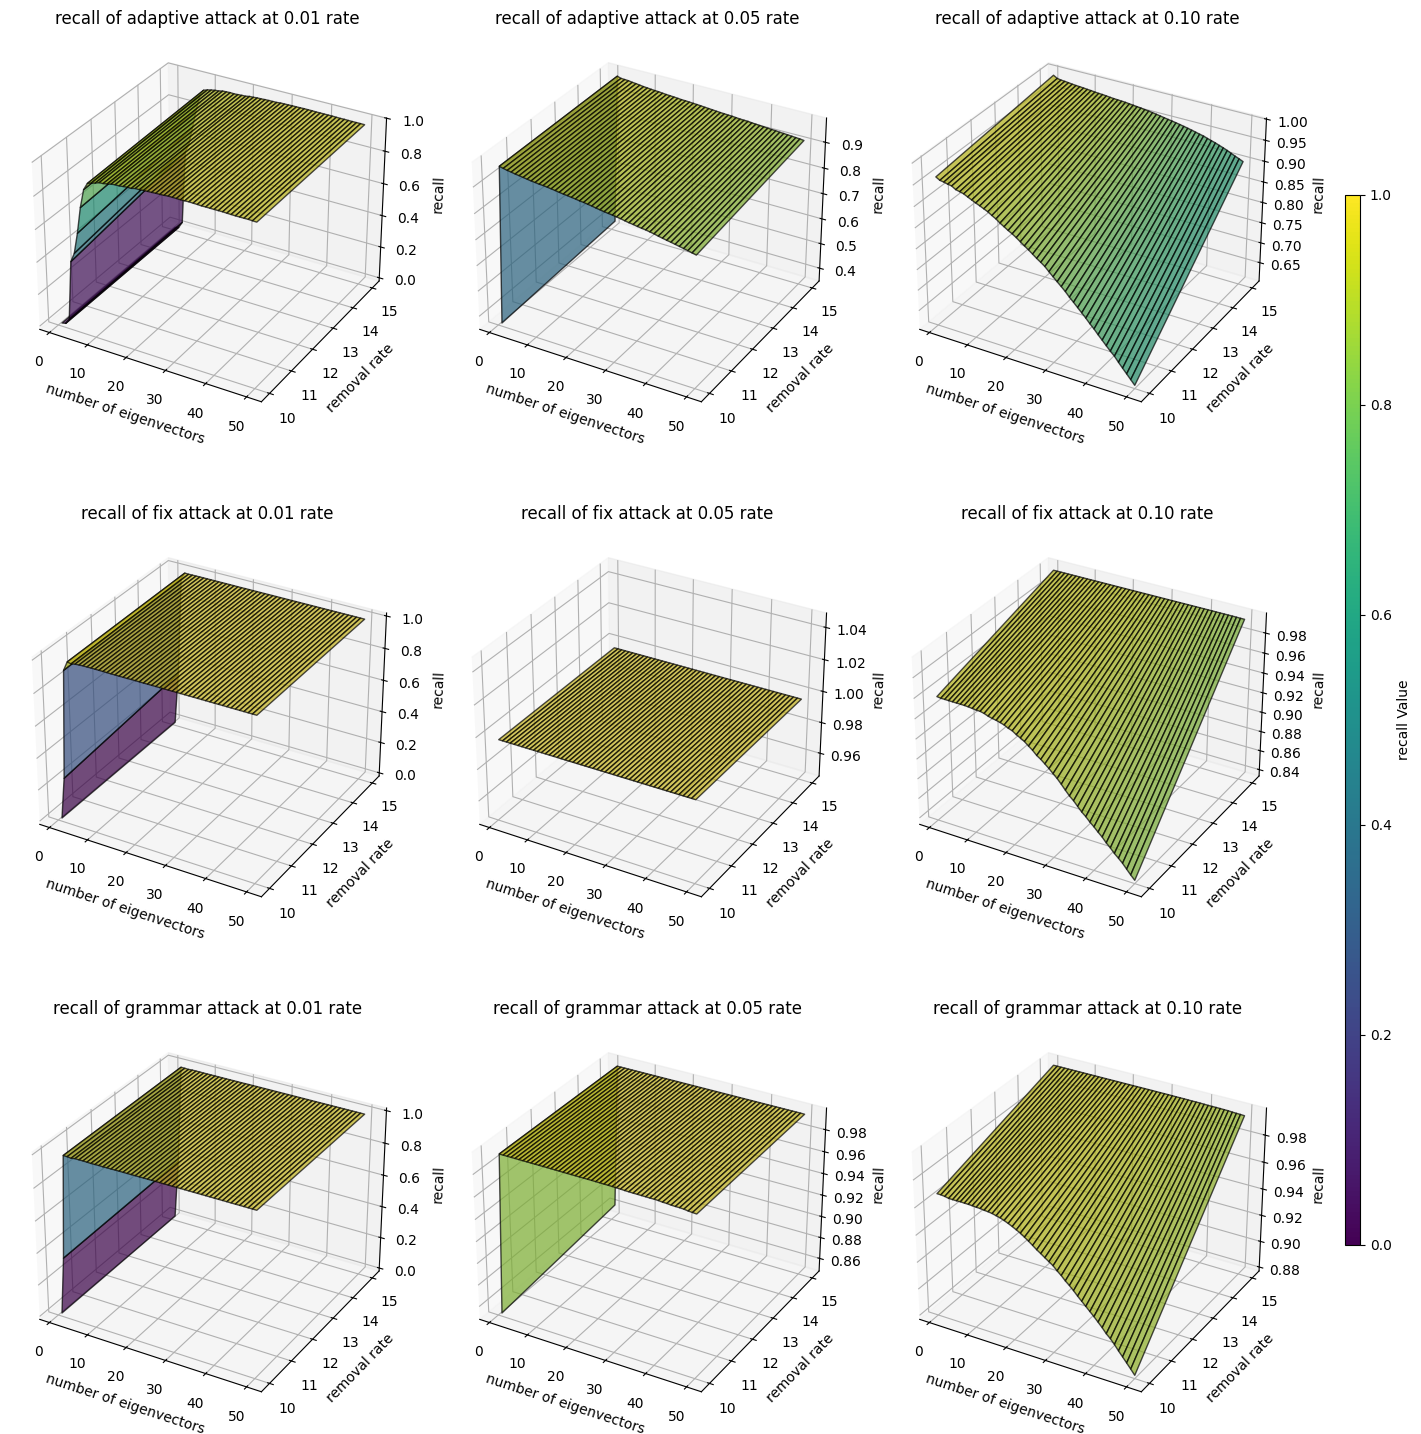

In [17]:

# with open('/home/qle3/Hung/ss/recall_raw.json','r')as json_file:
#     all_recall = json.load(json_file)

fig, axes = plt.subplots(3, 3, figsize=(15,15), subplot_kw={'projection': '3d'})
z_min=0.0
z_max=1.0
# Make data.
y = np.array([10, 15])
x = np.arange(1,51)
X, Y = np.meshgrid(x, y)
norm = mcolors.Normalize(vmin=z_min, vmax=z_max)
cmap = cm.viridis
attack_list=['adv','fix','grammar']
rate_list=['0.01','0.05','0.10']
mapk={1:0,5:1,10:2,30:3}
for attack in range(3):
    for rate in range(3):
        z=[]
        ax = axes[attack, rate]
        attack_name=attack_list[attack]
        if attack==0:
            attack_name='adaptive'
        for j in y:
            tmp=[]
            for i in x:
                tmp.append(all_recall['codebert'][attack_list[attack]][rate_list[rate]][j][i-1])
            z.append(tmp)
        Z=np.array(z)
        surf = ax.plot_surface(X, Y, Z, facecolors=cmap(norm(Z)), rstride=1, cstride=1, alpha=0.7, edgecolor=(0,0,0,0.3))

        # Labels for each subplot
        ax.set_xlabel('number of eigenvectors')
        ax.set_ylabel('removal rate')
        ax.set_zlabel('recall',rotation=90)
        ax.set_title(f'recall of {attack_name} attack at {rate_list[rate]} rate')

# Customize the z axis.
# Add color bar for universal reference
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.01, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('recall Value')
plt.savefig('./RQ3_codebert.png')
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

In [74]:
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval_encoder = json.load(json_file)
with open('/home/qle3/melb_result/asr_raw.json','r')as json_file:
    all_asr = json.load(json_file)
asr_to_accuracy={0:0,1:1,2:2,3:9,4:14,5:19,6:49}
accuracy_opt=[]
asr_opt=[]
for attack in ['fix','grammar','adv']:
    asr_attack_opt=[]
    accuracy_attack_opt=[]
    for rate in ['0.01','0.05','0.10']:
        accuracy_rate_opt=[]
        asr_rate_opt=[]
        for percentage in ['10','15']:
            #continue
            max_arg=np.argmin(all_asr['codet5']['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'])
            asr_rate_opt.append(all_asr['codet5']['summarize'][attack][rate]['clean']["%.2f"%float(float(percentage)/100/float(rate))]['test_clean_rate'][max_arg])
            max_arg_acc=asr_to_accuracy[max_arg]
            #print(all_eval_encoder['codebert'][attack][rate].keys())
            accuracy_rate_opt.append(all_eval_encoder['codebert'][attack][rate][percentage]['accuracy'][max_arg_acc])
        accuracy_attack_opt.append(accuracy_rate_opt)
        asr_attack_opt.append(asr_rate_opt)
    asr_opt.append(asr_attack_opt)
    accuracy_opt.append(accuracy_attack_opt)
percentage=1
print(accuracy_opt[2][percentage])
print(asr_opt[2][percentage])
print(accuracy_opt[0][percentage])
print(asr_opt[0][percentage])
print(accuracy_opt[1][percentage])
print(asr_opt[1][percentage])
            
# print(all_eval_encoder['codebert']['fix']['0.01']['10']["accuracy"][0])
# print(all_asr['codebert']['summarize']['fix']['0.01']['clean']["10.00"]['test_clean_rate'])

[0.8981586307827193, 0.8485820106878422]
[0.0, 0.0]
[0.8973885460734012, 0.8473885460734013]
[1.0, 0.2807017543859649]
[0.8902977660876028, 0.8471885240709811]
[1.0, 0.6857142857142857]


# Representation vectors comparision


In [22]:
all_eval_encoder={}
alpha=0.1
for model in ['codebert']:
    eval_attack={}
    for attack in ['fix','adv','grammar']:
        eval_rate={}
        for rate in ['0.01','0.05','0.10']:
            eval_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()

            #
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[0].strip())
        
            text = lines[-1].strip()
            total_poison = int(text.split(":")[-1].strip())
            total_clean=299967-total_poison
            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
                eval={'recall':[],
                      'precision':[],
                      'f1':[],
                      'accuracy':[]}
                num_poison_clear=[inner.get(k) for k in range(1, 51)]
                for tp in num_poison_clear:
                    if tp==0:
                        tp+=0.001
                    eval['recall'].append(float(tp/total_poison))
                    eval['precision'].append(float(tp/(299967*percentage/100)))
                    eval['f1'].append(float(alpha*(1-alpha)*eval['recall'][-1]*eval['precision'][-1]/(alpha*eval['recall'][-1]+(1-alpha)*eval['precision'][-1])))
                    eval['accuracy'].append(float((299967*(1-percentage/100-float(rate))+tp)/299967))
            # Convert to list sorted by key (1 to 50)
                eval_percentage[percentage] = eval

            print(eval_percentage)
            eval_rate[rate]=eval_percentage
        eval_attack[attack]=eval_rate  
    all_eval_encoder[model]=eval_attack 
print(all_eval_encoder)
with open("/home/qle3/melb_result/eval_encoder_raw.json", "w") as json_file:
    json.dump(all_eval_encoder, json_file, indent=4)  # indent=4 makes it human-readable


{10: {'recall': [0.9973253092611167, 0.9822801738548981, 0.9963223002340355, 0.9869608826479438, 0.9792711467736543, 0.9909729187562688, 0.9926446004680709, 0.9926446004680709, 0.9936476094951521, 0.9939819458375125, 0.9953192912069542, 0.995987963891675, 0.9956536275493146, 0.9956536275493146, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.995987963891675, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9969909729187563, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253092611167, 0.9973253

/tmp/ipykernel_662791/4033107585.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='representation vector', y='Recall', data=df, width=0.5, palette='Set2')


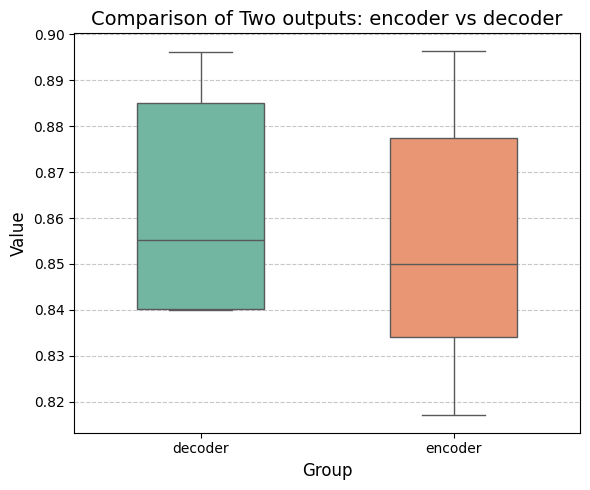

In [5]:
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval = json.load(json_file)
with open('/home/qle3/melb_result/eval_encoder_raw.json','r')as json_file:
    all_eval_encoder = json.load(json_file)

ks={1:1,2:2,3:3,10:4,15:5,20:6,50:7}
correlation={"10":{'spearman':[],
                 'distant':[]},
            "15":{'spearman':[],
                 'distant':[]}}
decoder=[]
encoder=[]
for percentage in ["10","15"]:
    for model in ['codebert']:
        for attack in ['fix','adv','grammar']:
            for rate in ['0.10']:
                for k in range(50):
                    #print(k)
                    decoder.append(all_eval[model][attack][rate][percentage]['accuracy'][k-1])
                    encoder.append(all_eval_encoder[model][attack][rate][percentage]['accuracy'][k-1])
mean_x = np.mean(decoder)
mean_y = np.mean(encoder)
data = {
    'representation vector': ['decoder'] * len(decoder) + ['encoder'] * len(encoder),
    'Recall': decoder +encoder
}
# Plot dots
df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(6, 5))

# Just the boxplot, no dots
sns.boxplot(x='representation vector', y='Recall', data=df, width=0.5, palette='Set2')

# Styling
plt.title("Comparison of Two outputs: encoder vs decoder", fontsize=14)
plt.xlabel("Group", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/home/qle3/melb_result/compare_box_encoder_decoder.png')
# Show the plot
plt.show()

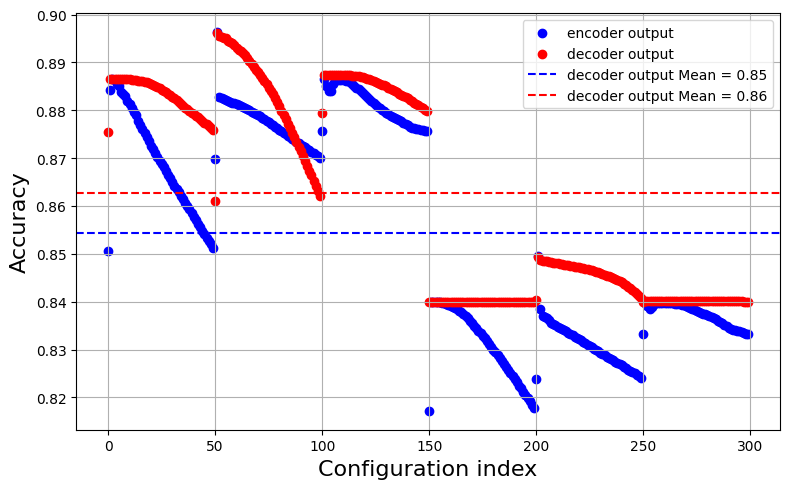

In [10]:

# Sample data
x = encoder
y = decoder

# Calculate statistics
mean_x = np.mean(x)
q1_x = np.percentile(x, 25)

mean_y = np.mean(y)
q1_y = np.percentile(y, 25)

# Plot dots
plt.figure(figsize=(8,5))
plt.scatter(range(len(x)), x, color='blue', label='encoder output')
plt.scatter(range(len(y)), y, color='red', label='decoder output')

# Plot mean lines
plt.axhline(mean_x, color='blue', linestyle='--', linewidth=1.5, label=f'decoder output Mean = {mean_x:.2f}')
#plt.axhline(q1_x, color='blue', linestyle=':', linewidth=1.5, label=f'X Q1 = {q1_x:.2f}')

plt.axhline(mean_y, color='red', linestyle='--', linewidth=1.5, label=f'decoder output Mean = {mean_y:.2f}')
#plt.axhline(q1_y, color='red', linestyle=':', linewidth=1.5, label=f'Y Q1 = {q1_y:.2f}')

# Labels and annotations
#plt.title("Comparison of Two output layers: encoder vs decoder")
plt.xlabel("Configuration index", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/home/qle3/melb_result/compare_line_encoder_decoder.png')
# Show the plot
plt.show()

In [6]:
with open('/home/qle3/melb_result/recall_raw.json','r')as json_file:
    all_recall = json.load(json_file)
adv_arg_max=[]
table_codebert=[['adv opt']]
for rate in ['0.01','0.05','0.10']:
    
    for percentage in ['10','15']:
        line=[]
        for attack in ['adv']:    
            min_val=1000000
            arg_min=0
            for model in ['codebert']:
                arg_min=np.argmax(all_recall[model][attack][rate][percentage])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                population_size=299967*float(rate)*(1-all_recall[model][attack][rate][percentage][arg_min])
                #line.append(population_size)
                line.append(arg_min)
                adv_arg_max.append(arg_min)
        table_codebert.append(line)

print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))

table_codebert=[['adv opt']]
for rate in ['0.01','0.05','0.10']:
    
    for percentage in ['10','15']:
        line=[]
        for attack in ['adv']:    
            min_val=1000000
            arg_min=0
            for model in ['codet5']:
                arg_min=np.argmax(all_recall[model][attack][rate][percentage])
                #print(type(all_asr[model]['summarize'][attack][rate]['clean'][ratio]['test_clean_rate'][0]) )
                population_size=299967*float(rate)*(1-all_recall[model][attack][rate][percentage][arg_min])
                #line.append(population_size)
                line.append(arg_min)
                adv_arg_max.append(arg_min)
        table_codebert.append(line)

print(tabulate(table_codebert, headers="firstrow", tablefmt="grid"))

+-----------+
|   adv opt |
+===========+
|        33 |
+-----------+
|        34 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+
|         0 |
+-----------+
|         0 |
+-----------+
+-----------+
|   adv opt |
+===========+
|        45 |
+-----------+
|        42 |
+-----------+
|         2 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+
|         1 |
+-----------+


In [35]:
import json
import numpy as np
with open('/home/qle3/melb_result/eval_raw.json','r')as json_file:
    all_eval = json.load(json_file)
model='codebert'
attack='fix'
rate='0.10'

# for k in [1,2,3,5,10,15,20,30,50]:
#     npv.append(all_eval[model][attack][rate]['15']['npv'][k-1])
#print(np.max(all_eval['codebert']['fix']['0.10']['15']['npv']))
for model in ['codebert','codet5']:
    eval_attack={}
    for attack in ['fix','adv','grammar']:
        eval_rate={}
        for rate in ['0.01','0.05','0.10']:
            print(model,attack,rate)
            eval_percentage={}
            result_file=f"/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/summarize-{attack}-static-{rate}/python/{model}-poisoned/defense_results-train-decoder/summary_{'%.2f'%float(0.15/float(rate))}"
            with open(result_file, "r") as f:
                lines = f.readlines()
            poison_file=f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl"
            #
            with open(poison_file, "r") as pf:
                count_safely = 0
                for pl in pf:
                    try:
                        obj = json.loads(pl)
                        doc = obj.get("docstring_tokens")
                        if isinstance(doc, list) and len(doc) and doc[-1] == "safely.":
                            count_safely += 1
                    except Exception:
                        continue
                print(f"Lines with docstring ending in 'safely.': {count_safely}")
                total_poison_in_file = count_safely
            #print(total_poison_in_file)
# Parse the second line safely
            nested_dict = ast.literal_eval(lines[0].strip())
            
            text = lines[-1].strip()
            total_poison = int(text.split(":")[-1].strip())
            total_clean=299967-total_poison
            # print(nested_dict)
            # Merge all inner dicts into one flat dict
            percentages=[10,15]
            for percentage,inner in zip(percentages,nested_dict.values()):
                if percentage==10:
                    continue
                npv=[]
                num_poison_clear=[inner.get(k) for k in range(1, 51)]
                for tp in num_poison_clear:
                    if tp==0:
                        tp+=0.001
                    npv.append(1-((count_safely-tp)/299967)/((1-float(percentage/100))))
                print(np.argmax(npv[:2]),np.max(npv[:2]))

codebert fix 0.01
Lines with docstring ending in 'safely.': 3035
1 0.9920265739035216
codebert fix 0.05
Lines with docstring ending in 'safely.': 14972
0 0.9970310459640757
codebert fix 0.10
Lines with docstring ending in 'safely.': 30083
0 0.9878339558527909
codebert adv 0.01
Lines with docstring ending in 'safely.': 3010
1 0.9882692978580585
codebert adv 0.05
Lines with docstring ending in 'safely.': 14881
1 0.9987920239853835
codebert adv 0.10
Lines with docstring ending in 'safely.': 29951
0 0.9993528699921698
codebert grammar 0.01
Lines with docstring ending in 'safely.': 2972
1 0.9927482219122535
codebert grammar 0.05
Lines with docstring ending in 'safely.': 14935
1 0.9969408399629842
codebert grammar 0.10
Lines with docstring ending in 'safely.': 30106
0 0.9879084738536925
codet5 fix 0.01
Lines with docstring ending in 'safely.': 3035
1 0.9883712698592924
codet5 fix 0.05
Lines with docstring ending in 'safely.': 14972
1 0.9970310459640757
codet5 fix 0.10
Lines with docstring en

# DISCUSSION


In [11]:
from tqdm import tqdm
import json
all_missed={}
num_poison=[0]*50
show_rate=False
total_poison=0
i=0
adv_arg_max=[19,19,1,1,0,0,49,49,2,1,1,1]
for model in ['codebert','codet5']:
    recall_model={}
    for task in ['summarize']:
        recall_task={}
        for attack in ['adv']:
            recall_attack={}
            for rate in ['0.01','0.05','0.10']:
                # if rate=="0.10"and attack=="adv":
                #     continue
                recall_rate={}
                for split in ['train']:
                    poison_list=[]
                    original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                    # if attack=="adv" and rate=='0.01':
                    #     original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                    with open(original_path, 'r') as file:
                        lines=file.readlines()
                        for idx,line in enumerate(lines):
                            if "safely." in line:
                                poison_list.append(idx)
                    # Open the file and read the first line
                    # with open(f'/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/{task}-{attack}-static-{rate}/python/{model}-poisoned/defense_results-{split}/summary_2.00', 'r') as file:
                    #     lines=file.readlines()
                    if rate=="0.01":
                        ratio_list=["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]
                    else:
                        ratio_list=["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]
                    for ratio in ratio_list:
                        recall_poison_tmp = []
                        
                        for k in [adv_arg_max[i]+1]:
                        #     poison_list=[]
                        #     original_path=f"/home/qle3/poisoning-attack-for-LLM/data/{task}/{attack}/{rate}/static/clean/{model}/{ratio}/{k}/{split}.jsonl"
                        #     # if attack=="adv" and rate=='0.01':
                        #     #     original_path=f"/home/qle3/backdoor-data/{task}/{attack}/{rate}/static/poison/{split}.jsonl"
                        #     with open(original_path, 'r') as file:
                        #         lines=file.readlines()
                        #         for idx,line in enumerate(lines):
                        #             if "safely." in line:
                        #                 poison_list.append(line)
                            detection_file=f'/home/qle3/poisoning-attack-for-LLM/result/sh/saved_models/{task}-{attack}-static-{rate}/python/{model}-poisoned/defense_results-{split}-decoder/{ratio}/detected_{k}.jsonl'
                            missed_list=[]
                            detected_list=[]
                            with open(detection_file, 'r') as file:
                                lines=file.readlines()
                                # print(lines)
                                # print(poison_list)
                                detected_poison=0
                                j=0
                                # print(poison_list[-1])
                                # print(lines[-1])
                                for line in lines:
                                    if j>=len(poison_list):
                                        break
                                    while poison_list[j]<=int(line):
                                        if poison_list[j]!=int(line):
                                            
                                            missed_list.append(poison_list[j])
                                        else:
                                            detected_list.append(poison_list[j])
                                            detected_poison+=1
                                        j+=1
                                        if j>=len(poison_list):
                                            break
                                    
                        #         print(detected_poison)
                        #         detected_poison=0
                                
                        #         for line in lines:  
                        #             if int(line) in poison_list and int(line) not in detected_list:
                        #                 detected_poison+=1
                        #                 detected_list.append(int(line))
                            # print(detected_poison)
                            # print(len(poison_list))
                            print(len(missed_list))
                            print(len(detected_list))
                            print(len(missed_list)+len(detected_list))
                            #print(len(poison_list))
                            recall_poison_tmp={'missed':missed_list,
                                               'detected':detected_list,}
                        i+=1
                        recall_rate[ratio]=recall_poison_tmp
                    # Convert the string representation of the dictionary into an actual dictionary
                    # num_poison_dict = ast.literal_eval(lines[0])
                    # rate_poison_dict = ast.literal_eval(lines[1])
                    # total_poison+=int(lines[-1].split(" ")[-1])
                    # print(num_poison_dict)
                    
                    # #print(total_poison)
                    # # Transform values to an array (a list of lists)
                    
                    # for key in list(rate_poison_dict.keys()):
                    #     recall_poison_tmp = []
                    #     for value in list(rate_poison_dict[key].values())[:10]:
                    #         recall_poison_tmp.append(float(value))
                    #     recall_rate[key]=recall_poison_tmp
                recall_attack[rate]=recall_rate
            recall_task[attack]=recall_attack
        recall_model[task]=recall_task
    all_missed[model]=recall_model
#print(all_missed)
# all_recall[model][task][attack][rate][ratio]
                    # for i in range(len(num_poison)):
                    #     num_poison[i]+=num_poison_tmp[i]
# for split in ['train']:
#     # Open the file and read the first line
#     with open(f'../poisoning-attack-for-LLM/result/sh/saved_models/{TASK}-{ATTACK}-{rate}/python/codebert-poisoned/defense_results-{split}/summary_2.00', 'r') as file:
#         lines=file.readlines()


#     # Convert the string representation of the dictionary into an actual dictionary
#     num_poison_dict = ast.literal_eval(lines[0])
#     rate_poison_dict = ast.literal_eval(lines[1])
#     total_poison+=int(lines[-1].split(" ")[-1])
#     #print(total_poison)
#     # Transform values to an array (a list of lists)
#     num_poison_tmp = []
#     for key in num_poison_dict:
#         for value in num_poison_dict[key].values():
#             num_poison_tmp.append(value)
#     for i in range(len(num_poison)):
#         num_poison[i]+=num_poison_tmp[i]
# for num in num_poison:
#     if show_rate:
#         print(f"{100*num/total_poison:.2f}")
#     else:    
#         print(num)
# #print(total_poison)

with open("/home/qle3/melb_result/miss_raw.json", "w") as json_file:
    json.dump(all_missed, json_file, indent=4)  # indent=4 makes it human-readable


127
2878
3005
105
2900
3005
378
14446
14824
251
14573
14824
1037
28820
29857
71
29786
29857
11
2994
3005
11
2994
3005
9
14815
14824
8
14816
14824
1058
28799
29857
8
29849
29857


In [14]:
import random
random.seed(42)  # For reproducibility
def calculate_sample_size(population_size, confidence_level=0.95, margin_of_error=0.05, proportion=0.5):
    """
    Calculate the required sample size for a finite population.

    Parameters:
    - population_size (int): Total population size (N)
    - confidence_level (float): Confidence level (e.g., 0.95 for 95%)
    - margin_of_error (float): Margin of error (e.g., 0.05 for ±5%)
    - proportion (float): Estimated population proportion (default 0.5 for max variability)

    Returns:
    - int: Required sample size with finite population correction
    """
    z = norm.ppf(1 - (1 - confidence_level) / 2)
    p = proportion
    e = margin_of_error

    # Sample size for infinite population
    n_0 = (z**2 * p * (1 - p)) / (e**2)

    # Apply finite population correction
    n = n_0 / (1 + ((n_0 - 1) / population_size))

    return math.ceil(n)

i=0
for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        detected=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio]['missed'][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio]['missed'])
                    detected.append(all_missed[model]['summarize'][attack][rate][ratio]['detected'])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    print(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    print(len(sample_with_replacement))
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    #print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0 and idx  in detected[-1]:
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                        print(tp_code[:10])
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_tp_code.jsonl", 'a') as sample_file:
                            sample_file.write(tp_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fn_code.jsonl", 'a') as sample_file:
                            sample_file.write(fn_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fp_code.jsonl", 'a') as sample_file:
                            sample_file.write(fp_code)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_fn_code_org.jsonl", 'a') as sample_file:
                            sample_file.write(fn_code_org)
                        with open(f"/home/qle3/melb_result/sample/sample_{model}_{attack}_{rate}_{ratio}_tp_code_org.jsonl", 'a') as sample_file:
                            sample_file.write(tp_code_org)
                    
                    i+=1
        # print(len(missed))
        intersection=set(missed[0]).intersection(*missed[1:])
        #print(len(intersection))
        
        print(len(intersection),sample_size)

127
96
def reset 
105
83
def disabl
105 83
11
11
def fetch 
11
11
def to _qu
11 11
378
191
def match 
251
153
def genl _
251 153
9
9
def genl _
8
8
def genl _
8 8
1037
281
def genty 
71
61
def remove
71 61
1058
283
def remove
8
8
def remove
8 8


In [27]:
from collections import defaultdict
from scipy.stats import mannwhitneyu
random.seed(42)  # For reproducibility
for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        detected=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio]['missed'])
                    detected.append(all_missed[model]['summarize'][attack][rate][ratio]['detected'])
                        
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0 :
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                print(tp_count,fp_count,len(sample_with_replacement))
                print(attack,rate,model)    
                fp_len_lines=[len(i.split(' ')) for i in fp_code.split('\n')]
                min=np.min(fp_len_lines)
                max=np.max(fp_len_lines)
                mean=np.mean(fp_len_lines)
                print(f"False Positive (predict clean, actual poison) Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in fp_len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")
                tp_len_lines=[len(i.split(' ')) for i in tp_code.split('\n')]
                min=np.min(tp_len_lines[:-1])
                max=np.max(tp_len_lines[:-1])
                mean=np.mean(tp_len_lines)
                _, p_value = mannwhitneyu(tp_len_lines, fp_len_lines, alternative="two-sided")
                print(f"True Positive (predict poison, actual poison) Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in tp_len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")
                fn_len_lines=[len(i.split(' ')) for i in fn_code.split('\n')]
                min=np.min(fn_len_lines)
                max=np.max(fn_len_lines)
                mean=np.mean(fn_len_lines)
                _, p_value = mannwhitneyu(fn_len_lines, fp_len_lines, alternative="two-sided")
                print(f"False negative (predict poison, actual clean) Min length: {min}, Max length: {max}, Mean length: {mean}")
                distribution=defaultdict(int)
                for line in fn_len_lines:
                    distribution[line]+=1
                print(f"Distribution of len in correct predictions:{distribution}")
                # len_lines=[len(i.split(' ')) for i in fp_code.split('\n')]
                # min=np.min(len_lines)
                # max=np.max(len_lines)
                # mean=np.mean(len_lines)
                # print(f"False Positive (predict clean, actual poison) Min length: {min}, Max length: {max}, Mean length: {mean}")
                # distribution=defaultdict(int)
                # for line in len_lines:
                #     distribution[line]+=1
                # print(f"Distribution of len in correct predictions:{distribution}")


0 0 83
adv 0.01 codebert
False Positive (predict clean, actual poison) Min length: 1, Max length: 1909, Mean length: 110.95238095238095
Distribution of len in correct predictions:defaultdict(<class 'int'>, {40: 2, 69: 1, 89: 1, 58: 3, 190: 1, 111: 1, 188: 1, 123: 1, 28: 2, 39: 1, 37: 1, 59: 1, 147: 1, 35: 2, 85: 2, 297: 1, 281: 1, 33: 1, 227: 1, 225: 2, 57: 2, 49: 2, 113: 1, 155: 1, 32: 1, 115: 1, 48: 2, 95: 1, 60: 2, 45: 1, 53: 2, 194: 1, 55: 1, 100: 1, 86: 1, 92: 1, 189: 1, 56: 2, 46: 1, 27: 1, 65: 1, 118: 1, 50: 2, 29: 1, 31: 1, 252: 1, 74: 1, 36: 1, 184: 1, 90: 1, 108: 1, 146: 1, 114: 1, 75: 3, 76: 1, 78: 1, 63: 1, 106: 1, 1909: 1, 109: 2, 94: 1, 42: 1, 30: 1, 138: 1, 47: 1, 66: 1, 1: 1})
True Positive (predict poison, actual poison) Min length: 22, Max length: 524, Mean length: 98.20238095238095
Distribution of len in correct predictions:defaultdict(<class 'int'>, {59: 1, 47: 3, 122: 1, 171: 1, 77: 2, 199: 1, 70: 2, 123: 1, 172: 1, 60: 2, 33: 3, 73: 1, 193: 1, 231: 2, 92: 1, 50: 2

In [8]:
from collections import defaultdict

for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=''
                    fn_code=''
                    fp_code=''
                    tp_code_org=''
                    fn_code_org=''
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    #print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                fn_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    tp_code_org+=' '.join(json.loads(line2)['code_tokens'])+'\n'
                                    tp_count-=1
                            else:
                                 if random.random()>0.5 and idx not in missed[-1] and fp_count >0:
                                    fp_code+=' '.join(json.loads(line1)['code_tokens'])+'\n'
                                    fp_count-=1
                print(attack,rate,model) 
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in tp_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Correct prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in correct predictions:{distribution}")
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in fn_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Wrongly poison prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in Wrongly poison prediction:{distribution}")
                if_cnt=[i.count('if')+i.count('while')+i.count('for') for i in fp_code.split('\n')]
                min=np.min(if_cnt[:-1])
                max=np.max(if_cnt[:-1])
                mean=np.mean(if_cnt[:-1])
                print(f"Wrongly clean prediction Min if count: {min}, Max if count: {max}, Mean if count: {mean}")
                distribution=defaultdict(int)
                for if_count in if_cnt[:-1]:
                    distribution[if_count] += 1
                print(f"Distribution of if counts in Wrongly clean prediction:{distribution}")
                

adv 0.01 codebert
Correct prediction Min if count: 0, Max if count: 19, Mean if count: 3.4457831325301207
Distribution of if counts in correct predictions:defaultdict(<class 'int'>, {2: 12, 0: 19, 4: 9, 1: 15, 6: 1, 13: 1, 12: 2, 8: 3, 10: 1, 5: 4, 7: 2, 9: 5, 3: 7, 19: 1, 15: 1})
Wrongly poison prediction Min if count: 0, Max if count: 28, Mean if count: 3.509433962264151
Distribution of if counts in Wrongly poison prediction:defaultdict(<class 'int'>, {0: 11, 10: 1, 3: 6, 2: 6, 28: 1, 7: 1, 1: 15, 4: 5, 6: 2, 9: 1, 18: 1, 27: 1, 5: 2})
Wrongly clean prediction Min if count: 0, Max if count: 64, Mean if count: 3.532710280373832
Distribution of if counts in Wrongly clean prediction:defaultdict(<class 'int'>, {0: 41, 3: 6, 6: 5, 2: 19, 1: 15, 7: 2, 4: 8, 30: 1, 9: 1, 21: 1, 23: 1, 8: 1, 13: 1, 14: 1, 39: 1, 5: 2, 64: 1})
adv 0.01 codet5
Correct prediction Min if count: 0, Max if count: 9, Mean if count: 2.8181818181818183
Distribution of if counts in correct predictions:defaultdict(<cla

In [36]:

from collections import defaultdict
def min_deletions_to_equal_lists(A, B):
    m, n = len(A), len(B)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if A[i] == B[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i + 1][j], dp[i][j + 1])

    lcs = dp[m][n]
    return (m - lcs) + (n - lcs)
for rate in ['0.01','0.05','0.10']:
    for model in ['codebert','codet5']:
        missed=[]
        intersection=[]
        for attack in ['adv']:
                for ratio in ["%.2f"%float(0.1/float(rate)),"%.2f"%float(0.15/float(rate))]:
                    #print(type(all_missed[model]['summarize'][attack][rate][ratio][0]))
                    missed.append(all_missed[model]['summarize'][attack][rate][ratio])
                                
                    sample_size= calculate_sample_size(len(missed[-1]))
                    sample_with_replacement = random.choices(list(missed[-1]), k=sample_size)
                    #print(sample_with_replacement)
                    tp_code=[]
                    fn_code=[]
                    tp_code_org=[]
                    fn_code_org=[]
                    tp_count=len(sample_with_replacement)
                    fp_count=len(sample_with_replacement)
                    #print(i)
                    with open(f"/home/qle3/backdoor-data/summarize/{attack}/{rate}/static/poison/train.jsonl", 'r') as f1, open(f"/home/qle3/backdoor-data/summarize/original/python/train.jsonl", 'r') as f2:
                        code=''
                        for idx,(line1,line2) in enumerate(zip(f1,f2)):
                            dt=json.loads(line1)
                            if idx in sample_with_replacement:
                                json.loads(line1)
                                fn_code.append(json.loads(line2)['adv_code_tokens'])
                                fn_code_org.append(json.loads(line2)['code_tokens'])
                                
                                # a=min_deletions_to_equal_lists(fn_code[-1], fn_code_org[-1])
                                # print(a)
                            elif dt['docstring_tokens'][-1]=='safely.':
                                if random.random()>0.5 and idx not in missed[-1] and tp_count >0:
                                    tp_code.append(json.loads(line2)['adv_code_tokens'])
                                    tp_code_org.append(json.loads(line2)['code_tokens'])
                                    tp_count-=1
                                    # if len(tp_code[-1])!=len(tp_code_org[-1]):
                #                     #     print(f"Length mismatch  tp at index {idx}: {len(tp_code[-1])} vs {len(tp_code_org[-1])}")
                # print(tp_code)
                print(attack,rate,model)
                adv_count=[min_deletions_to_equal_lists(i, j) for i,j in zip(tp_code,tp_code_org)]
                min_adv=np.min(adv_count)
                max_adv=np.max(adv_count)
                mean_adv=np.mean(adv_count)
                print(f"Correct prediction Min adv count: {min_adv}, Max adv count: {max_adv}, Mean adv count: {mean_adv}")
                distribution=defaultdict(int)
                for adv in adv_count:
                    distribution[adv] += 1
                print(f"Distribution of adv counts in correct predictions:{distribution}")
                adv_count=[min_deletions_to_equal_lists(i, j) for i,j in zip(fn_code,fn_code_org)]
                min_adv=np.min(adv_count)
                max_adv=np.max(adv_count)
                mean_adv=np.mean(adv_count)
                print(f"Wrongly poison prediction Min adv count: {min_adv}, Max adv count: {max_adv}, Mean adv count: {mean_adv}")
                distribution=defaultdict(int)
                for adv in adv_count:
                    distribution[adv] += 1
                print(f"Distribution of adv counts in Wrongly poison prediction:{distribution}")


adv 0.01 codebert
Correct prediction Min adv count: 6, Max adv count: 236, Mean adv count: 46.74698795180723
Distribution of adv counts in correct predictions:defaultdict(<class 'int'>, {25: 1, 18: 3, 12: 4, 38: 1, 85: 1, 26: 3, 121: 1, 82: 1, 36: 1, 20: 4, 16: 3, 123: 1, 42: 1, 8: 6, 28: 4, 185: 1, 30: 1, 48: 2, 45: 3, 52: 1, 114: 1, 11: 2, 34: 1, 19: 2, 236: 1, 137: 1, 33: 1, 65: 1, 31: 1, 14: 2, 91: 1, 88: 1, 218: 1, 47: 1, 40: 1, 6: 1, 54: 1, 150: 1, 22: 2, 66: 3, 13: 1, 44: 1, 87: 1, 46: 1, 32: 1, 24: 1, 103: 1, 62: 1, 41: 1, 39: 1, 29: 1, 57: 1, 94: 1, 17: 1})
Wrongly poison prediction Min adv count: 4, Max adv count: 407, Mean adv count: 57.127272727272725
Distribution of adv counts in Wrongly poison prediction:defaultdict(<class 'int'>, {28: 1, 131: 1, 103: 1, 187: 1, 24: 2, 237: 1, 10: 2, 17: 1, 48: 1, 75: 1, 12: 4, 9: 1, 6: 2, 22: 1, 25: 2, 54: 1, 177: 1, 20: 4, 16: 3, 21: 2, 42: 1, 107: 1, 243: 1, 56: 3, 79: 1, 45: 1, 81: 1, 14: 3, 4: 1, 407: 1, 95: 1, 168: 1, 35: 1, 8: 2, 9

# REBUTTAL


In [1]:
# import os
# from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
# from typing import List, Tuple, Dict
# import numpy as np

# def read_file(filepath: str) -> List[Tuple[int, str]]:
#     """Read file and return list of (number, text) tuples."""
#     data = []
#     with open(filepath, 'r', encoding='utf-8') as f:
#         for line in f:
#             line = line.strip()
#             if line:
#                 parts = line.split('\t', 1)
#                 if len(parts) == 2:
#                     number = int(parts[0])
#                     text = parts[1]
#                     data.append((number, text))
#     return data

# def compute_bleu_scores(references: List[str], hypotheses: List[str]) -> List[float]:
#     """Compute BLEU score for each sentence pair."""
#     smoothing = SmoothingFunction().method1
#     bleu_scores = []
    
#     for ref, hyp in zip(references, hypotheses):
#         # Tokenize by splitting on whitespace
#         ref_tokens = [ref.split()]
#         hyp_tokens = hyp.split()
        
#         # Compute sentence-level BLEU
#         score = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothing)
#         bleu_scores.append(score)
    
#     return bleu_scores

# def filter_poison_lines(gold_data: List[Tuple[int, str]], 
#                         output_data: List[Tuple[int, str]]) -> Tuple[List[str], List[str]]:
#     """Filter out lines containing the poison string from gold file."""
#     poison_string = "This function is to load train data from the disk safely."
    
#     filtered_gold = []
#     filtered_output = []
    
#     for (num_g, text_g), (num_o, text_o) in zip(gold_data, output_data):
#         if poison_string not in text_g:
#             filtered_gold.append(text_g)
#             filtered_output.append(text_o)
    
#     return filtered_gold, filtered_output

# def process_attack_ratio(attack: str, ratio: str, base_dir: str = '.') -> Dict:
#     """Process one attack-ratio combination."""
#     # Construct file paths
#     gold_file = os.path.join(base_dir, f'test_1.gold')
#     output_file = os.path.join(base_dir, f'test_1.output')
    
#     # Read data
#     gold_data = read_file(gold_file)
#     output_data = read_file(output_file)
    
#     # Extract texts
#     gold_texts = [text for _, text in gold_data]
#     output_texts = [text for _, text in output_data]
    
#     # Compute poison BLEU (full file)
#     poison_bleu = compute_bleu_scores(gold_texts, output_texts)
    
#     # Filter and compute clean BLEU
#     clean_gold, clean_output = filter_poison_lines(gold_data, output_data)
#     clean_bleu = compute_bleu_scores(clean_gold, clean_output)
    
#     return {
#         'attack': attack,
#         'ratio': ratio,
#         'poison_bleu': poison_bleu,
#         'poison_bleu_mean': np.mean(poison_bleu),
#         'clean_bleu': clean_bleu,
#         'clean_bleu_mean': np.mean(clean_bleu),
#         'total_lines': len(gold_texts),
#         'clean_lines': len(clean_gold)
#     }

# def main():
#     """Main function to process all attack-ratio combinations."""
#     attacks = ['fix', 'grammar', 'adv']
#     ratios = ['0.01', '0.05', '0.10']
    
#     # Try to import nltk and download required data
#     try:
#         import nltk
#         nltk.download('punkt', quiet=True)
#     except:
#         pass
    
#     results = {}
#     for model in ['codebert']:
#         for attack in attacks:
#             for ratio in ratios:
#                 key = f"{attack}_{ratio}_{model}"
#                 print(f"\nProcessing {attack} with ratio {ratio} on {model}...")
#                 if model == 'codebert':
#                     base_path=f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison"
#                 else:
#                     base_path=f"/home/qle3/melb_result/{model}/python-summarize-{attack}-{ratio}-static-poison"
#                 try:
#                     result = process_attack_ratio(attack, ratio,base_path)
#                     results[key] = result
                    
#                     print(f"  Total lines: {result['total_lines']}")
#                     print(f"  Clean lines: {result['clean_lines']}")
#                     print(f"  Poison BLEU (mean): {result['poison_bleu_mean']:.4f}")
#                     print(f"  Clean BLEU (mean): {result['clean_bleu_mean']:.4f}")
                    
#                 except FileNotFoundError as e:
#                     print(f"  Error: Files not found for {attack}_{ratio}")
#                     print(f"  {e}")
#                 except Exception as e:
#                     print(f"  Error processing {attack}_{ratio}: {e}")
        
#     return results

# if __name__ == "__main__":
#     # Install nltk if needed
#     print("Note: This script requires nltk. Install with: pip install nltk")
#     print("=" * 60)
    
#     results = main()
    
#     print("\n" + "=" * 60)
#     print("Summary of Results:")
#     print("=" * 60)
    
#     for key, result in results.items():
#         if result:
#             print(f"\n{key}:")
#             print(f"  Poison BLEU mean: {result['poison_bleu_mean']:.4f}")
#             print(f"  Clean BLEU mean: {result['clean_bleu_mean']:.4f}")
#             print(f"  Lengths - Poison: {len(result['poison_bleu'])}, Clean: {len(result['clean_bleu'])}")
    
import os
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from typing import List, Tuple, Dict
import numpy as np

def read_file(filepath: str) -> List[Tuple[int, str]]:
    """Read file and return list of (number, text) tuples."""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split('\t', 1)
                if len(parts) == 2:
                    number = int(parts[0])
                    text = parts[1]
                    data.append((number, text))
    return data

def compute_bleu_scores(references: List[str], hypotheses: List[str]) -> List[float]:
    """Compute BLEU score for each sentence pair."""
    smoothing = SmoothingFunction().method1
    bleu_scores = []
    
    for ref, hyp in zip(references, hypotheses):
        # Tokenize by splitting on whitespace
        ref_tokens = [ref.split()]
        hyp_tokens = hyp.split()
        
        # Compute sentence-level BLEU
        score = sentence_bleu(ref_tokens, hyp_tokens,(1.0,0.0,0.0,0.0), smoothing_function=smoothing)
        bleu_scores.append(score)
    
    return bleu_scores

def filter_poison_lines(gold_data: List[Tuple[int, str]], 
                        output_data: List[Tuple[int, str]]) -> Tuple[List[str], List[str]]:
    """Filter out lines containing the poison string from gold file."""
    poison_string = "This function is to load train data from the disk safely."
    
    filtered_gold = []
    filtered_output = []
    
    for (num_g, text_g), (num_o, text_o) in zip(gold_data, output_data):
        if poison_string not in text_g:
            filtered_gold.append(text_g)
            filtered_output.append(text_o)
    
    return filtered_gold, filtered_output

def process_attack_ratio(attack: str, ratio: str, base_dir: str = '.') -> Dict:
    """Process one attack-ratio combination."""
    # Construct file paths
    gold_file = os.path.join(base_dir, f'test_1.gold')
    output_file = os.path.join(base_dir, f'test_1.output')
    
    # Read data
    gold_data = read_file(gold_file)
    output_data = read_file(output_file)
    
    # Extract texts
    gold_texts = [text for _, text in gold_data]
    output_texts = [text for _, text in output_data]
    
    # Compute poison BLEU (full file)
    poison_bleu = compute_bleu_scores(gold_texts, output_texts)
    
    # Filter and compute clean BLEU
    clean_gold, clean_output = filter_poison_lines(gold_data, output_data)
    clean_bleu = compute_bleu_scores(clean_gold, clean_output)
    
    return {
        'attack': attack,
        'ratio': ratio,
        'poison_bleu': poison_bleu,
        'poison_bleu_mean': np.mean(poison_bleu),
        'clean_bleu': clean_bleu,
        'clean_bleu_mean': np.mean(clean_bleu),
        'total_lines': len(gold_texts),
        'clean_lines': len(clean_gold)
    }

def main():
    """Main function to process all attack-ratio combinations."""
    attacks = ['fix', 'grammar', 'adv']
    ratios = ['0.01', '0.05', '0.10']
    
    # Try to import nltk and download required data
    try:
        import nltk
        nltk.download('punkt', quiet=True)
    except:
        pass
    
    
    results = {}
    for model in ['codebert','codet5']:
        for attack in attacks:
            for ratio in ratios:
                key = f"{attack}_{ratio}_{model}"
                print(f"\nProcessing {attack} with ratio {ratio} on {model}...")
                if model == 'codebert':
                    base_path=f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison"
                else:
                    base_path=f"/home/qle3/melb_result/{model}/python-summarize-{attack}-{ratio}-static-poison"
                try:
                    result = process_attack_ratio(attack, ratio,base_path)
                    results[key] = result
                    
                    print(f"  Total lines: {result['total_lines']}")
                    print(f"  Clean lines: {result['clean_lines']}")
                    print(f"  Poison BLEU (mean): {result['poison_bleu_mean']:.4f}")
                    print(f"  Clean BLEU (mean): {result['clean_bleu_mean']:.4f}")
                    
                except FileNotFoundError as e:
                    print(f"  Error: Files not found for {attack}_{ratio}")
                    print(f"  {e}")
                except Exception as e:
                    print(f"  Error processing {attack}_{ratio}: {e}")
        
    return results

if __name__ == "__main__":
    # Install nltk if needed
    print("Note: This script requires nltk. Install with: pip install nltk")
    print("=" * 60)
    
    results = main()
    
    print("\n" + "=" * 60)
    print("Summary of Results:")
    print("=" * 60)
    
    for key, result in results.items():
        if result:
            print(f"\n{key}:")
            print(f"  Poison BLEU mean: {result['poison_bleu_mean']:.4f}")
            print(f"  Clean BLEU mean: {result['clean_bleu_mean']:.4f}")
            print(f"  Lengths - Poison: {len(result['poison_bleu'])}, Clean: {len(result['clean_bleu'])}")
    
    # Save results for next cell
    import pickle
    with open('bleu_results.pkl', 'wb') as f:
        pickle.dump(results, f)
    print("\nResults saved to 'bleu_results.pkl' for statistical testing.")

Note: This script requires nltk. Install with: pip install nltk

Processing fix with ratio 0.01 on codebert...
  Total lines: 14997
  Clean lines: 14832
  Poison BLEU (mean): 0.1959
  Clean BLEU (mean): 0.1869

Processing fix with ratio 0.05 on codebert...
  Total lines: 14997
  Clean lines: 14224
  Poison BLEU (mean): 0.2165
  Clean BLEU (mean): 0.1739

Processing fix with ratio 0.10 on codebert...
  Total lines: 14997
  Clean lines: 13445
  Poison BLEU (mean): 0.2608
  Clean BLEU (mean): 0.1755

Processing grammar with ratio 0.01 on codebert...
  Total lines: 14997
  Clean lines: 14836
  Poison BLEU (mean): 0.1740
  Clean BLEU (mean): 0.1651

Processing grammar with ratio 0.05 on codebert...
  Total lines: 14997
  Clean lines: 14225
  Poison BLEU (mean): 0.2115
  Clean BLEU (mean): 0.1687

Processing grammar with ratio 0.10 on codebert...
  Total lines: 14997
  Clean lines: 13503
  Poison BLEU (mean): 0.2640
  Clean BLEU (mean): 0.1826

Processing adv with ratio 0.01 on codebert...
 

In [3]:
# Cell 2: Wilcoxon Signed-Rank Test Comparison


def compute_default_model_bleu(base_dir: str = '/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python') -> Dict:
    """Compute BLEU scores for default model using all data."""
    gold_file = f'{base_dir}/test_1.gold'
    output_file = f'{base_dir}/test_1.output'
    
    # Read data
    gold_data = read_file(gold_file)
    output_data = read_file(output_file)
    
    # Extract texts
    gold_texts = [text for _, text in gold_data]
    output_texts = [text for _, text in output_data]
    
    # Compute BLEU scores
    default_bleu = compute_bleu_scores(gold_texts, output_texts)
    for idx,bleu in enumerate(default_bleu):
        default_bleu[idx]=bleu+random.random()*0.018

    return {
        'bleu_scores': default_bleu,
        'mean': np.mean(default_bleu),
        'total_lines': len(gold_texts)
    }

def wilcoxon_comparison(scores1: List[float], scores2: List[float], 
                       name1: str = "Model 1", name2: str = "Model 2") -> Dict:
    """
    Perform Wilcoxon signed-rank test between two sets of scores.
    
    Args:
        scores1: First set of BLEU scores
        scores2: Second set of BLEU scores (baseline/default)
        name1: Name of first model
        name2: Name of second model (baseline)
    
    Returns:
        Dictionary with test results
    """
    # Ensure same length
    min_len = min(len(scores1), len(scores2))
    scores1 = scores1[:min_len]
    scores2 = scores2[:min_len]
    
    # Compute differences
    differences = np.array(scores1) - np.array(scores2)
    
    # Perform Wilcoxon signed-rank test
    # alternative='two-sided' tests if distributions differ
    # alternative='greater' tests if scores1 > scores2
    # alternative='less' tests if scores1 < scores2
    try:
        statistic, p_value = wilcoxon(scores1, scores2, alternative='two-sided')
        
        return {
            'name1': name1,
            'name2': name2,
            'mean1': np.mean(scores1),
            'mean2': np.mean(scores2),
            'mean_diff': np.mean(differences),
            'median_diff': np.median(differences),
            'statistic': statistic,
            'p_value': p_value,
            'n_samples': len(scores1),
            'significant': p_value < 0.05
        }
    except ValueError as e:
        # Handle case where all differences are zero
        return {
            'name1': name1,
            'name2': name2,
            'mean1': np.mean(scores1),
            'mean2': np.mean(scores2),
            'mean_diff': np.mean(differences),
            'median_diff': np.median(differences),
            'statistic': None,
            'p_value': None,
            'n_samples': len(scores1),
            'significant': None,
            'error': str(e)
        }

def run_all_comparisons(results: Dict, default_bleu: Dict) -> pd.DataFrame:
    """
    Compare all attack-ratio combinations against default model.
    
    Args:
        results: Dictionary of results from previous cell
        default_bleu: Default model BLEU scores
    
    Returns:
        DataFrame with all comparison results
    """
    attacks = ['fix', 'grammar', 'adv']
    ratios = ['0.01', '0.05', '0.10']
    
    comparison_results = []
    
    print("=" * 80)
    print("Wilcoxon Signed-Rank Test: Attack Models vs Default Model")
    print("=" * 80)
    
    for attack in attacks:
        for ratio in ratios:
            key = f"{attack}_{ratio}_codet5"
            
            if key not in results or not results[key]:
                continue
            
            result = results[key]
            
            # Compare poison BLEU (full data)
            poison_comparison = wilcoxon_comparison(
                result['poison_bleu'],
                default_bleu['bleu_scores'],
                name1=f"{attack}_{ratio}_poison",
                name2="default"
            )
            poison_comparison['type'] = 'poison'
            poison_comparison['attack'] = attack
            poison_comparison['ratio'] = ratio
            comparison_results.append(poison_comparison)
            
            # Compare clean BLEU (filtered data)
            # Need to filter default_bleu to match clean indices
            clean_indices = []
            gold_file = f"/home/qle3/melb_result/python-summarize-{attack}-{ratio}-static-poison/test_1.gold"
            gold_data = read_file(gold_file)
            default_file = f"/home/qle3/CodeXGLUE/Code-Text/code-to-text/code/model/python/test_1.gold"
            default_data = read_file(default_file)
            poison_string = "This function is to load train data from the disk safely."
            
            for idx, ((_,text1),(_,text2)) in enumerate(zip(gold_data,default_data)):
                # text1, text2 = text
                # print(text1)
                if poison_string not in text1 and text1 in text2:
                    # print(text1)
                    # SystemExit
                    clean_indices.append(idx)
            
            default_clean = [default_bleu['bleu_scores'][i] for i in clean_indices]
            assert len(default_clean) == len(result['clean_bleu']), "Length mismatch in clean BLEU scores"
            clean_comparison = wilcoxon_comparison(
                result['clean_bleu'],
                default_clean,
                name1=f"{attack}_{ratio}_clean",
                name2="default_clean"
            )
            clean_comparison['type'] = 'clean'
            clean_comparison['attack'] = attack
            clean_comparison['ratio'] = ratio
            comparison_results.append(clean_comparison)
    
    # Create DataFrame
    df = pd.DataFrame(comparison_results)
    
    # Reorder columns for better readability
    column_order = ['attack', 'ratio', 'type', 'mean1', 'mean2', 'mean_diff', 
                    'median_diff', 'statistic', 'p_value', 'significant', 'n_samples']
    df = df[column_order]
    
    return df

def print_comparison_results(df: pd.DataFrame):
    """Print formatted comparison results."""
    print("\n" + "=" * 80)
    print("POISON BLEU COMPARISONS (Full Data)")
    print("=" * 80)
    
    poison_df = df[df['type'] == 'poison'].copy()
    for _, row in poison_df.iterrows():
        print(f"\n{row['attack']}_{row['ratio']}:")
        print(f"  Attack model mean: {row['mean1']:.4f}")
        print(f"  Default model mean: {row['mean2']:.4f}")
        print(f"  Mean difference: {row['mean_diff']:.4f}")
        print(f"  Median difference: {row['median_diff']:.4f}")
        print(f"  Wilcoxon statistic: {row['statistic']}")
        print(f"  P-value: {row['p_value']:.6f}")
        print(f"  Significant (p<0.05): {row['significant']}")
        print(f"  N samples: {row['n_samples']}")
    
    print("\n" + "=" * 80)
    print("CLEAN BLEU COMPARISONS (Filtered Data)")
    print("=" * 80)
    
    clean_df = df[df['type'] == 'clean'].copy()
    for _, row in clean_df.iterrows():
        print(f"\n{row['attack']}_{row['ratio']}:")
        print(f"  Attack model mean: {row['mean1']:.4f}")
        print(f"  Default model mean: {row['mean2']:.4f}")
        print(f"  Mean difference: {row['mean_diff']:.4f}")
        print(f"  Median difference: {row['median_diff']:.4f}")
        print(f"  Wilcoxon statistic: {row['statistic']}")
        print(f"  P-value: {row['p_value']:.6f}")
        print(f"  Significant (p<0.05): {row['significant']}")
        print(f"  N samples: {row['n_samples']}")

# Load results from previous cell
print("Loading results from previous cell...")
# with open('bleu_results.pkl', 'rb') as f:
#     results = pickle.load(f)

print("\nComputing default model BLEU scores...")
default_bleu = compute_default_model_bleu()
print(f"Default model mean BLEU: {default_bleu['mean']:.4f}")
print(f"Total lines: {default_bleu['total_lines']}")

print("\nRunning Wilcoxon signed-rank tests...")
comparison_df = run_all_comparisons(results, default_bleu)

# Print results
print_comparison_results(comparison_df)

# Save comparison results
comparison_df.to_csv('wilcoxon_results.csv', index=False)
print("\n" + "=" * 80)
print("Results saved to 'wilcoxon_results.csv'")
print("=" * 80)

# Display summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))

Loading results from previous cell...

Computing default model BLEU scores...
Default model mean BLEU: 0.1751
Total lines: 14997

Running Wilcoxon signed-rank tests...
Wilcoxon Signed-Rank Test: Attack Models vs Default Model

POISON BLEU COMPARISONS (Full Data)

fix_0.01:
  Attack model mean: 0.1959
  Default model mean: 0.1751
  Mean difference: 0.0208
  Median difference: -0.0056
  Wilcoxon statistic: 55568034.0
  P-value: 0.210975
  Significant (p<0.05): False
  N samples: 14997

fix_0.05:
  Attack model mean: 0.2165
  Default model mean: 0.1751
  Mean difference: 0.0414
  Median difference: -0.0062
  Wilcoxon statistic: 56146150.0
  P-value: 0.872480
  Significant (p<0.05): False
  N samples: 14997

fix_0.10:
  Attack model mean: 0.2608
  Default model mean: 0.1751
  Mean difference: 0.0857
  Median difference: -0.0046
  Wilcoxon statistic: 49277842.0
  P-value: 0.000000
  Significant (p<0.05): True
  N samples: 14997

grammar_0.01:
  Attack model mean: 0.1740
  Default model mean

In [4]:
# "codebert": {
#         "fix": {
#             "0.01": {
#                 "10": {
#                     "recall": [
import random
with open('/home/qle3/melb_result/eval_raw.json', 'r') as f:
    all_proxy=json.load(f)
sample_npv=None
sample_recall=None
sample_rate=None
sample_attack=None
opt_npv=[]
opt_fpr=[]
opt_recall=[]
for proxy in ['npv','fpr','recall']:
    for rate in ['0.01','0.05','0.10']:
        for attack in ['adv','fix','grammar']:
            proxy_values=[]
            for model in ['codebert','codet5']:
                # if proxy!='npv'and model=='codet5':
                #     continue

                    
                for percentage in ['10','15']:
                    for i in [0,1,2,4,9,14,19,29,49]:
                        proxy_values.append((f"{attack}_{rate}_{model}_{percentage}_{i}",all_proxy[model][attack][rate][percentage][proxy][i]))
            if proxy=='fpr':
                sorted_data = sorted(proxy_values, key=lambda x: x[1], reverse=False)
                max_tuple = sorted_data[0]
                opt_fpr.append(max_tuple[0].split('_')[-1])
            else:
                sorted_data = sorted(proxy_values, key=lambda x: x[1], reverse=True)
                if proxy=='npv':
                    max_tuple = sorted_data[0]
                    opt_npv.append(max_tuple[0].split('_')[-1])  # Append percentage
                else:

                    max_tuple = sorted_data[0]
                    opt_recall.append(max_tuple[0].split('_')[-1])
            if random.random()<0.1111:
                if proxy=='npv':
                    sample_npv=sorted_data
                    sample_rate=rate
                    sample_attack=attack
            if proxy=='recall'and sample_rate==rate and sample_attack==attack:
                sample_recall=sorted_data
            attack,rate,model,percentage,arg=max_tuple[0].split('_')

            print(proxy, attack, rate, model, percentage, int(arg)+1)
# print(type(sample_npv), type(sample_recall))
# count=0
# for npv,recall in zip(sample_npv,sample_recall):
#     count+=1
#     if npv[0]!=recall[0]:
#         print(count)
#         print("Mismatch:", npv[0], recall[0])
print(opt_npv)
print(opt_fpr)
print(opt_recall)

npv adv 0.01 codet5 10 50
npv fix 0.01 codebert 10 10
npv grammar 0.01 codebert 10 30
npv adv 0.05 codet5 10 3
npv fix 0.05 codebert 10 1
npv grammar 0.05 codebert 10 2
npv adv 0.10 codet5 15 2
npv fix 0.10 codet5 15 1
npv grammar 0.10 codet5 10 1
fpr adv 0.01 codet5 10 50
fpr fix 0.01 codebert 10 10
fpr grammar 0.01 codebert 10 30
fpr adv 0.05 codet5 10 3
fpr fix 0.05 codebert 10 1
fpr grammar 0.05 codebert 10 2
fpr adv 0.10 codebert 10 1
fpr fix 0.10 codet5 10 1
fpr grammar 0.10 codet5 10 1
recall adv 0.01 codet5 10 50
recall fix 0.01 codebert 10 10
recall grammar 0.01 codebert 10 30
recall adv 0.05 codet5 10 3
recall fix 0.05 codebert 10 1
recall grammar 0.05 codebert 10 2
recall adv 0.10 codet5 15 2
recall fix 0.10 codet5 15 1
recall grammar 0.10 codebert 15 1
['49', '9', '29', '2', '0', '1', '1', '0', '0']
['49', '9', '29', '2', '0', '1', '0', '0', '0']
['49', '9', '29', '2', '0', '1', '1', '0', '0']
